# Giros Tesorales

In [901]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [902]:
giros = {}
crp = {}

In [903]:
df = pd.read_csv("giros.csv", sep=";")

C:\Users\DVadeus\AppData\Local\Temp\ipykernel_13292\3658427298.py:1: DtypeWarning: Columns (38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("giros.csv", sep=";")


In [904]:
df.head(20)

,Vigencia,ID_Giro,Número de orden de pago,Orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Tipo de giro,Razon_Social,...,Valor Neto,Cuenta contable,Debito,Credito,ID_Soporte,Pagado,Valor sanción,Valor Intereses,Valor Multas,Valor Reconexion
0,2021,ORDEN DE PAGO,2991,SI,1088259568,3/02/2021,1.272702e+11,BANCO DAVIVIENDA S.A.,Transferencia,YONNY ANDRES CRUZ BENJUMEA,...,$ 1.499.478,1110,NaN,$ 1.499.478,2991,SI,$ -,$ -,$ -,$ -
1,2021,ORDEN DE PAGO,2992,SI,1088259568,3/02/2021,1.272702e+11,BANCO DAVIVIENDA S.A.,Transferencia,YONNY ANDRES CRUZ BENJUMEA,...,$ 312.500,1110,NaN,$ 312.500,2992,SI,$ -,$ -,$ -,$ -
2,2021,ORDEN DE PAGO,3001,SI,52539367,4/02/2021,5.700089e+14,BANCO DAVIVIENDA S.A.,Transferencia,ALEXANDRA VARGAS PINILLA,...,$ 7.290.786,1110,NaN,$ 7.290.786,3001,SI,$ -,$ -,$ -,$ -
3,2021,ORDEN DE PAGO,3047,SI,1094938732,8/02/2021,1.202372e+08,BANCOLOMBIA S A,Transferencia,MARIA ALEJANDRA LONDOÑO JIMENEZ,...,$ 1.447.500,1110,NaN,$ 1.447.500,3047,SI,$ -,$ -,$ -,$ -
4,2021,ORDEN DE PAGO,3053,SI,1093773164,8/02/2021,5.704574e+14,BANCO DAVIVIENDA S.A.,Transferencia,JURGEN DANIEL TOLOZA DELGADO,...,$ 6.184.861,1110,NaN,$ 6.184.861,3053,SI,$ -,$ -,$ -,$ -
5,2021,ORDEN DE PAGO,3065,SI,1088303099,9/02/2021,2.700005e+10,BANCOLOMBIA S A,Transferencia,SILVIA ABAD HERNANDEZ,...,$ 4.866.140,1110,NaN,$ 4.866.140,3065,SI,$ -,$ -,$ -,$ -
6,2021,ORDEN DE PAGO,3067,SI,7515099,9/02/2021,4.654375e+10,BANCOLOMBIA S A,Transferencia,LUIS EDUARDO HERNANDEZ SAENZ,...,$ 6.039.863,1110,NaN,$ 6.039.863,3067,SI,$ -,$ -,$ -,$ -
7,2021,ORDEN DE PAGO,3068,SI,4520638,9/02/2021,7.214361e+10,BANCOLOMBIA S A,Transferencia,JHONATAN FELIPE SALDARRIAGA MEJIA,...,$ 3.649.605,1110,NaN,$ 3.649.605,3068,SI,$ -,$ -,$ -,$ -
8,2021,ORDEN DE PAGO,3069,SI,25181384,9/02/2021,4.510566e+08,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,Transferencia,MARIA ANDREA VILLALBA YATE,...,$ 4.866.140,1110,NaN,$ 4.866.140,3069,SI,$ -,$ -,$ -,$ -
9,2021,ORDEN DE PAGO,3070,SI,24644591,9/02/2021,2.595133e+08,BANCO DAVIVIENDA S.A.,Transferencia,PATRICIA ELENA MONTES GIRALDO,...,$ 4.866.140,1110,NaN,$ 4.866.140,3070,SI,$ -,$ -,$ -,$ -


## Descripción de los datos

In [905]:
df.dtypes

Vigencia                        int64
ID_Giro                        object
Número de orden de pago         int64
Orden de pago                  object
ID_Tercero                      int64
Fecha Giro                     object
Número de cuenta              float64
Banco                          object
Tipo de giro                   object
Razon_Social                   object
Tipo de persona                object
Tipo de gasto                  object
Fecha CRP                      object
CRP                             int64
Fecha CDP                      object
CDP                             int64
Anulado                        object
Valor Bruto                    object
IVA                            object
Actividad gravada IVA          object
Porcentaje ICA                 object
ICA                            object
Actividad gravada ICA          object
Porcentaje ReteFte             object
ReteFte                        object
ReteICA                        object
ReteIVA     

#### Datos nulos

In [906]:
df.isnull().sum()

Vigencia                          0
ID_Giro                           0
Número de orden de pago           0
Orden de pago                     0
ID_Tercero                        0
Fecha Giro                        0
Número de cuenta                415
Banco                           415
Tipo de giro                      0
Razon_Social                      0
Tipo de persona                   0
Tipo de gasto                     0
Fecha CRP                         0
CRP                               0
Fecha CDP                         0
CDP                               0
Anulado                        4687
Valor Bruto                       0
IVA                               0
Actividad gravada IVA         16272
Porcentaje ICA                 2468
ICA                               0
Actividad gravada ICA          4303
Porcentaje ReteFte                0
ReteFte                           0
ReteICA                           0
ReteIVA                           0
Estampilla                  

In [907]:
len(df)

16900

## Fase 0 - Entendimiento y limpieza

In [908]:
df.describe()

,Vigencia,Número de orden de pago,ID_Tercero,Número de cuenta,CRP,CDP,Cuenta contable,Debito,ID_Soporte
count,16900.000000,16900.000000,1.690000e+04,1.648500e+04,16900.000000,16900.000000,16900.0,0.0,16900.000000
mean,2022.299822,5257.367929,5.225799e+08,1.758401e+14,1158.881775,822.403373,1110.0,NaN,5257.367929
std,0.897485,3307.084036,5.017273e+08,3.215965e+15,870.650874,555.367156,0.0,NaN,3307.084036
min,2021.000000,1.000000,2.631771e+06,3.210000e+03,1.000000,1.000000,1110.0,NaN,1.000000
25%,2022.000000,2390.000000,4.549553e+07,5.832006e+09,481.750000,349.000000,1110.0,NaN,2390.000000
50%,2022.000000,5110.500000,8.087536e+07,2.410796e+10,976.000000,780.000000,1110.0,NaN,5110.500000
75%,2023.000000,7781.000000,1.051679e+09,9.122909e+10,1583.000000,1156.000000,1110.0,NaN,7781.000000
max,2024.000000,12801.000000,1.238339e+09,1.307030e+17,4222.000000,2785.000000,1110.0,NaN,12801.000000


#### Observaciones

- Número de cuenta: Los números de cuentas bancarías son generalmente entre 10 a 20 dígitos. Sin embargo encontramos una cuenta bancaria de 4 dígitos.
- Todos los giros fueron registrados en la cuenta 1110 Bancos

### Eliminación de características

Enumeración de características

In [909]:
df.columns

Index(['Vigencia', 'ID_Giro', 'Número de orden de pago', 'Orden de pago',
       'ID_Tercero', 'Fecha Giro', 'Número de cuenta', 'Banco', 'Tipo de giro',
       'Razon_Social', 'Tipo de persona', 'Tipo de gasto', 'Fecha CRP', 'CRP',
       'Fecha CDP', 'CDP', 'Anulado', 'Valor Bruto', 'IVA',
       'Actividad gravada IVA', 'Porcentaje ICA', 'ICA',
       'Actividad gravada ICA', 'Porcentaje ReteFte', 'ReteFte', 'ReteICA',
       'ReteIVA', 'Estampilla', 'Estampilla Universidad FJC', 'Adulto mayor',
       'Otros descuentos', 'Total descuentos', 'Valor Neto', 'Cuenta contable',
       'Debito', 'Credito', 'ID_Soporte', 'Pagado', 'Valor sanción',
       'Valor Intereses', 'Valor Multas', 'Valor Reconexion'],
      dtype='object')

De los 16900 giros presentes en el set de datos encontramos que las siguientes características:

- Debito: No contiene datos
- Actividad gravada IVA: 16.272 datos nulos, solo 628 datos tienen actividad gravada en IVA
- Anulado: 4.687 datos nulos
- Banco y Número de cuenta: **415** Datos nulos
- Sanción, Intereses, Multas y Reconexión: A pesar de que aparezcan con datos, únicamente contienen el siguiente dato: ``' $ -   '``

In [910]:
print(f"ID_Giros: {set(df["ID_Giro"])}")
print(f"Orden de pago: {set(df["Orden de pago"])}")
print(f"Tipo de giro: {set(df["Tipo de giro"])}")
print(f"Anulado: {set(df["Anulado"])}")
print(f"Valor sanción: {set(df["Valor sanción"])}")
print(f"Valor Intereses: {set(df["Valor Intereses"])}")
print(f"Valor Multas: {set(df["Valor Multas"])}")
print(f"Valor Reconexion: {set(df["Valor Reconexion"])}")
print(f"Debito: {set(df["Debito"])}")
print(f"Pagado: {set(df["Pagado"])}")

ID_Giros: {'ORDEN DE PAGO'}
Orden de pago: {'SI'}
Tipo de giro: {'Transferencia'}
Anulado: {'NO', nan}
Valor sanción: {nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, n

In [911]:
col_eliminar = [
    "ID_Giro",
    "Orden de pago",
    "Tipo de giro",
    "Anulado",
    "Valor sanción",
    "Valor Intereses",
    "Valor Multas",
    "Valor Reconexion",
    "Debito",
    "Pagado"
]

df.drop(col_eliminar, axis = 1, inplace = True)

### Transformación de tipos de columna

#### Verificación de que todos los ``ID_Tercero`` sean de tipo número

In [912]:
is_all_numeric = pd.to_numeric(df['ID_Tercero'], errors='coerce').notnull().all()
is_all_numeric

np.True_

#### Columnas de tipo número

In [913]:
numeric_cols = [
    "Valor Bruto",
    "IVA",
    "ICA",
    "ReteFte",
    "ReteICA",
    "ReteIVA",
    "Estampilla",
    "Estampilla Universidad FJC",
    "Adulto mayor",
    "Otros descuentos",
    "Total descuentos",
    "Valor Neto",
    "Credito"
]

In [914]:
for col in numeric_cols:
        if col in df.columns:
            print(f"Modificando: {col}")
            df[col] = df[col].str.replace('$', '', regex = False).str.strip()
            df[col] = df[col].str.replace('.','', regex = False)
            df[col] = pd.to_numeric(df[col], errors = "coerce")

Modificando: Valor Bruto
Modificando: IVA
Modificando: ICA
Modificando: ReteFte
Modificando: ReteICA
Modificando: ReteIVA
Modificando: Estampilla
Modificando: Estampilla Universidad FJC
Modificando: Adulto mayor
Modificando: Otros descuentos
Modificando: Total descuentos
Modificando: Valor Neto
Modificando: Credito


#### Columnas de tipo fecha

En la característica ``"Fecha CRP"`` existen 2 registros con el dato ``"#N/D"``

In [915]:
df[df["Fecha CRP"] == "#N/D"]

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,ReteIVA,Estampilla,Estampilla Universidad FJC,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,ID_Soporte
3560,2022,7449,1018424802,3/03/2022,6.027118e+10,BANCOLOMBIA S A,LIZ YORLENY RODRIGUEZ GOMEZ,NATURAL,SERVICIOS,#N/D,...,NaN,5833.0,NaN,23333.0,NaN,30093.0,1136573,1110,1136573,7449
3856,2022,8046,80192761,24/06/2022,2.452748e+10,BANCO CAJA SOCIAL S.A.,AGAPITO CASTRO CASTRO,NATURAL,SERVICIOS,#N/D,...,NaN,4167.0,NaN,16667.0,NaN,20834.0,812499,1110,812499,8046


#### ✅ Agregar indices al diccionario de giros

In [916]:
for idx in df[df["Fecha CRP"] == "#N/D"].index.to_list():
    crp.update({idx:"Fecha CRP Nula"})

#### Modificación de Fechas nulas CDP

Se imputaron valores faltantes en ``Fecha CRP`` utilizando `Fecha CDP`, dado que se identificó que los registros con valor ``#N/D`` corresponden a inconsistencias de captura y ambas fechas deberían coincidir según la lógica del proceso.”

In [917]:
df["Fecha CRP"] = df["Fecha CRP"].replace("#N/D", pd.NA)
df["Fecha CRP"] = df["Fecha CRP"].fillna(df["Fecha CDP"])

In [918]:
fecha_cols = [
    'Fecha Giro',
    'Fecha CRP',
    'Fecha CDP']

for fecha in fecha_cols:
    if fecha in df.columns:
        df[fecha] = pd.to_datetime(df[fecha], format='%d/%m/%Y')

#### Columnas de tipo categórica

In [919]:
categ_col = [
    'Tipo de persona',
    'Tipo de gasto',
    'Actividad gravada IVA',
    'Actividad gravada ICA'
]

In [920]:
for categ in categ_col:
    if categ in df.columns:
        df[categ] = df[categ].astype('category')

### Transformación de datos

#### Porcentajes de ICA y RteFte

In [921]:
set(df['Porcentaje ReteFte'])

{' $ -   ',
 ' HONORARIOS 11% ',
 ' RETEFUENTE ARRIENDOS 3.5% ',
 ' RETEFUENTE ARRIENDOS 4.0% ',
 ' RETEFUENTE COMPRAS 2.5% ',
 ' RETEFUENTE CONSULTORIA 11% ',
 ' RETEFUENTE EMPLEADOS ART. 383 E.T. ',
 ' RETEFUENTE SERVICIOS DE TRANSPORTE 3.5% ',
 ' SERVICIOS 2% ',
 ' SERVICIOS 4% ',
 '0',
 'HONORARIOS 10%',
 'HONORARIOS 11%',
 'HONORARIOS LEY 1450 2011',
 'RETEFUENTE A TRABAJADORES POR CUENTA PROPIA',
 'RETEFUENTE ARRIENDOS 3.5%',
 'RETEFUENTE COMPRAS 2.5%',
 'RETEFUENTE COMPRAS 3.5%',
 'RETEFUENTE CONSULTORIA 11%',
 'RETEFUENTE EMPLEADOS ART. 383 E.T.',
 'RETEFUENTE SERVICIOS DE TRANSPORTE 3.5%',
 'SERVICIOS 1%',
 'SERVICIOS 2%',
 'SERVICIOS 3.5%',
 'SERVICIOS 4%'}

In [922]:
df['Porcentaje ReteFte'] = df['Porcentaje ReteFte'].replace(' $ -   ', pd.NA)
df['Porcentaje ReteFte'] = df['Porcentaje ReteFte'].replace('0', pd.NA)

In [923]:
set(df['Porcentaje ReteFte'])

{' HONORARIOS 11% ',
 ' RETEFUENTE ARRIENDOS 3.5% ',
 ' RETEFUENTE ARRIENDOS 4.0% ',
 ' RETEFUENTE COMPRAS 2.5% ',
 ' RETEFUENTE CONSULTORIA 11% ',
 ' RETEFUENTE EMPLEADOS ART. 383 E.T. ',
 ' RETEFUENTE SERVICIOS DE TRANSPORTE 3.5% ',
 ' SERVICIOS 2% ',
 ' SERVICIOS 4% ',
 <NA>,
 'HONORARIOS 10%',
 'HONORARIOS 11%',
 'HONORARIOS LEY 1450 2011',
 'RETEFUENTE A TRABAJADORES POR CUENTA PROPIA',
 'RETEFUENTE ARRIENDOS 3.5%',
 'RETEFUENTE COMPRAS 2.5%',
 'RETEFUENTE COMPRAS 3.5%',
 'RETEFUENTE CONSULTORIA 11%',
 'RETEFUENTE EMPLEADOS ART. 383 E.T.',
 'RETEFUENTE SERVICIOS DE TRANSPORTE 3.5%',
 'SERVICIOS 1%',
 'SERVICIOS 2%',
 'SERVICIOS 3.5%',
 'SERVICIOS 4%'}

In [924]:
set(df['Porcentaje ICA'])


{'0',
 'RETEICA - ARMENIA - PROFESIONAL Y TÉCNICO',
 'RETEICA - ARMENIA - SERVICIO TRANSPORTE',
 'RETEICA - CTGENA ARRENDAMIENTO',
 'RETEICA - CTGENA SERV. TEC. Y PROF.',
 'RETEICA - CTGENA SERV. TRANSPORTE',
 'RETEICA - CTGENA VIGILANCIA Y TEMPORALES',
 'RETEICA - DOSQUEBRADAS SERV. TEC Y PROF.',
 'RETEICA - DOSQUEBRADAS SERVICIO TRANSPORTE',
 'RETEICA - GENERAL 0.5',
 'RETEICA - GENERAL 0.8',
 'RETEICA - PEREIRA ARRENDAMIENTOS',
 'RETEICA - PEREIRA SERV. PROFESIONALES',
 'RETEICA - PEREIRA SERV. TECNICOS',
 'RETEICA - PEREIRA SERV. TRANSPORTE',
 'RETEICA - SERVICIOS - SEGUROS GENERALES',
 'RETEICA 11.04% BIENES',
 'RETEICA 13.8% SERVICIOS',
 'RETEICA 6.9% BIENES',
 'RETEICA 6.9% SERVICIOS',
 'RETEICA 7.66% SERVICIOS',
 'RETEICA 8.66% SERVICIOS',
 'RETEICA 9.66% BIENES',
 'RETEICA 9.66% SERVICIOS',
 'RETEICA PALMIRA ARRENDAMIENTOS',
 'RETEICA PALMIRA SERV. TEC. Y PROF.',
 'RETEICA PALMIRA SERVICIOS',
 'RETEICA PALMIRA TRANSPORTE',
 'RETEICA S. ROSA DE CABAL ARRENDAMIENTO',
 'RETEICA S

In [925]:
df['Porcentaje ICA'] = df['Porcentaje ICA'].replace('0', pd.NA)
df['Porcentaje ICA'] = df['Porcentaje ICA'].fillna(pd.NA)

In [926]:
set(df['Porcentaje ICA'])

{<NA>,
 'RETEICA - ARMENIA - PROFESIONAL Y TÉCNICO',
 'RETEICA - ARMENIA - SERVICIO TRANSPORTE',
 'RETEICA - CTGENA ARRENDAMIENTO',
 'RETEICA - CTGENA SERV. TEC. Y PROF.',
 'RETEICA - CTGENA SERV. TRANSPORTE',
 'RETEICA - CTGENA VIGILANCIA Y TEMPORALES',
 'RETEICA - DOSQUEBRADAS SERV. TEC Y PROF.',
 'RETEICA - DOSQUEBRADAS SERVICIO TRANSPORTE',
 'RETEICA - GENERAL 0.5',
 'RETEICA - GENERAL 0.8',
 'RETEICA - PEREIRA ARRENDAMIENTOS',
 'RETEICA - PEREIRA SERV. PROFESIONALES',
 'RETEICA - PEREIRA SERV. TECNICOS',
 'RETEICA - PEREIRA SERV. TRANSPORTE',
 'RETEICA - SERVICIOS - SEGUROS GENERALES',
 'RETEICA 11.04% BIENES',
 'RETEICA 13.8% SERVICIOS',
 'RETEICA 6.9% BIENES',
 'RETEICA 6.9% SERVICIOS',
 'RETEICA 7.66% SERVICIOS',
 'RETEICA 8.66% SERVICIOS',
 'RETEICA 9.66% BIENES',
 'RETEICA 9.66% SERVICIOS',
 'RETEICA PALMIRA ARRENDAMIENTOS',
 'RETEICA PALMIRA SERV. TEC. Y PROF.',
 'RETEICA PALMIRA SERVICIOS',
 'RETEICA PALMIRA TRANSPORTE',
 'RETEICA S. ROSA DE CABAL ARRENDAMIENTO',
 'RETEICA 

La columna ``"Actividad gravada IVA"`` cuenta con datos con espacios en blanco los cuales serán arreglados.

In [927]:
print(f"Actividad gravada IVA: {set(df["Actividad gravada IVA"])}")

Actividad gravada IVA: {'SERVICIOS', 'BIENES', ' ARRENDAMIENTO ', 'ARRENDAMIENTO', ' SERVICIOS ', nan}


In [928]:
df["Actividad gravada IVA"] = df["Actividad gravada IVA"].str.replace(' ', '')

In [929]:
print(f"Actividad gravada IVA: {set(df["Actividad gravada IVA"])}")

Actividad gravada IVA: {'SERVICIOS', 'BIENES', 'ARRENDAMIENTO', nan}


#### Rellenar datos nulos con 0 

Para las características:

- IVA
- ICA
- ReteFte
- ReteICA
- ReteIVA
- Estampilla
- Estampilla Universidad FJC
- Adulto mayor
- Otros descuentos
- Total descuentos


In [930]:
rellenar_col = [
    'IVA',
    'ICA',
    'ReteFte',
    'ReteICA',
    'ReteIVA',
    'Estampilla',
    'Estampilla Universidad FJC',
    'Adulto mayor',
    'Otros descuentos',
    'Total descuentos'
]

In [931]:
for rellenar in rellenar_col:
    if rellenar in df.columns:
        df[rellenar] = df[rellenar].fillna(0)

### Creación de ID Compuesto

No existe un identificador único para cada giro tesoral, es por ello que se creará uno apartir de las siguientes características:

In [932]:
df["id_unico"] = (
    df["Número de orden de pago"].astype(str) + "_" +
    df["ID_Tercero"].astype(str) + "_"
)

## Fase 1 - Análisis descriptivo

In [933]:
df.describe()

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Fecha CRP,CRP,Fecha CDP,CDP,Valor Bruto,...,ReteIVA,Estampilla,Estampilla Universidad FJC,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,ID_Soporte
count,16900.000000,16900.000000,1.690000e+04,16900,1.648500e+04,16900,16900.000000,16900,16900.000000,1.690000e+04,...,1.690000e+04,1.690000e+04,1.690000e+04,1.690000e+04,16900.000000,1.690000e+04,1.690000e+04,16900.0,1.690000e+04,16900.000000
mean,2022.299822,5257.367929,5.225799e+08,2022-12-02 01:08:35.502958592,1.758401e+14,2022-09-09 09:58:09.230769408,1158.881775,2022-04-27 09:36:56.236686592,822.403373,5.877725e+06,...,2.548412e+04,2.013478e+04,8.993479e+03,8.054960e+04,0.761243,2.856534e+05,5.592072e+06,1110.0,5.592072e+06,5257.367929
min,2021.000000,1.000000,2.631771e+06,2021-01-22 00:00:00,3.210000e+03,2021-01-21 00:00:00,1.000000,2021-01-04 00:00:00,1.000000,2.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,2.000000e+00,1110.0,2.000000e+00,1.000000
25%,2022.000000,2390.000000,4.549553e+07,2022-04-06 00:00:00,5.832006e+09,2022-01-28 00:00:00,481.750000,2022-01-04 00:00:00,349.000000,1.933920e+06,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,4.344000e+04,1.877514e+06,1110.0,1.877514e+06,2390.000000
50%,2022.000000,5110.500000,8.087536e+07,2022-11-11 00:00:00,2.410796e+10,2022-08-03 00:00:00,976.000000,2022-06-03 00:00:00,780.000000,3.500000e+06,...,0.000000e+00,1.350800e+04,0.000000e+00,5.403300e+04,0.000000,1.055540e+05,3.381490e+06,1110.0,3.381490e+06,5110.500000
75%,2023.000000,7781.000000,1.051679e+09,2023-08-03 00:00:00,9.122909e+10,2023-03-08 00:00:00,1583.000000,2022-06-24 00:00:00,1156.000000,5.145984e+06,...,0.000000e+00,2.315700e+04,0.000000e+00,9.262800e+04,0.000000,1.596790e+05,4.982409e+06,1110.0,4.982409e+06,7781.000000
max,2024.000000,12801.000000,1.238339e+09,2024-12-30 00:00:00,1.307030e+17,2024-12-26 00:00:00,4222.000000,2024-10-03 00:00:00,2785.000000,1.975339e+09,...,7.249007e+06,7.493740e+06,5.423418e+06,2.997496e+07,12865.000000,5.339692e+07,1.958420e+09,1110.0,1.958420e+09,12801.000000
std,0.897485,3307.084036,5.017273e+08,NaN,3.215965e+15,NaN,870.650874,NaN,555.367156,3.553053e+07,...,2.543437e+05,9.051015e+04,1.182126e+05,3.620412e+05,98.961538,1.561749e+06,3.456304e+07,0.0,3.456304e+07,3307.084036


### Volumen de giros

#### Total giros por Año

In [934]:
df["año"] = df["Fecha Giro"].dt.year
df["mes"] = df["Fecha Giro"].dt.month

In [935]:
giro_anio = df.groupby(["año"])['Valor Neto'].sum().reset_index(name = 'Valor neto total')
giro_anio

,año,Valor neto total
0,2021,17033502564
1,2022,43654379673
2,2023,25701594635
3,2024,8116535412


Hay una distribución anormal en los datos para la característica ``"Valor Neto Total"`` cruzuado con ``"Año"``. 
- Presentando al año 2022 con el gasto tesoral más elevado de los 4 años

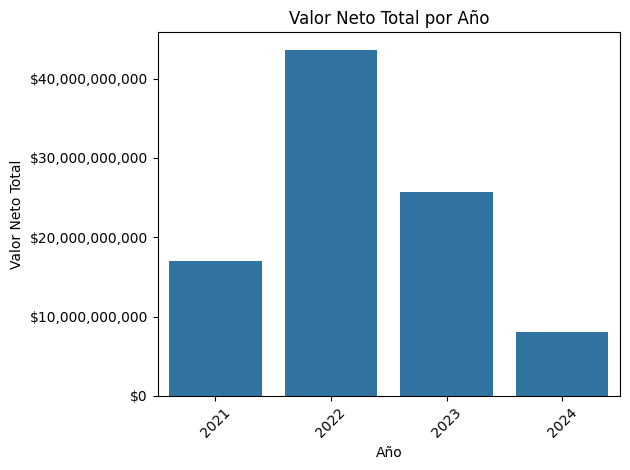

In [936]:
plt.figure()
ax = sns.barplot(data=giro_anio, x="año", y="Valor neto total")

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.title("Valor Neto Total por Año")
plt.xlabel("Año")
plt.ylabel("Valor Neto Total")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### ⚠️ Por revisar

Revisando la variación porcentual encontramos:

- Un crecimiento en el año 2022 de un 150% con respecto al año 2021.
- Un decremento en el año 2023 de aproximadamente un 40% con respecto al año 2022.
- Un decremento en el año 2024 de apróximadamente un 60% con respecto al año 2023.

Indicando al año 2022 como año clave a auditar.

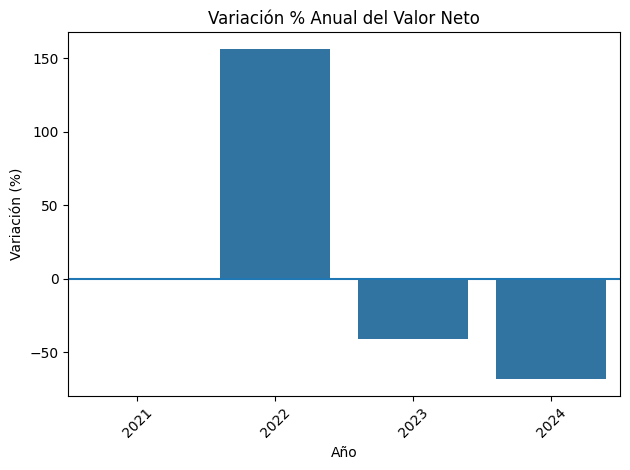

In [937]:
giro_anio["variacion_%"] = giro_anio["Valor neto total"].pct_change() * 100

plt.figure()
sns.barplot(data=giro_anio, x="año", y="variacion_%")

plt.title("Variación % Anual del Valor Neto")
plt.xlabel("Año")
plt.ylabel("Variación (%)")

plt.axhline(0)  # línea base
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Análisis temporal mes - año

In [938]:
giro_mes = df.groupby(["año", "mes"])['Valor Neto'].sum().reset_index(name = 'Valor neto total')
giro_mes

,año,mes,Valor neto total
0,2021,1,5611062
1,2021,2,259588481
2,2021,3,544824649
3,2021,4,1871642323
4,2021,5,780815694
5,2021,6,582381923
6,2021,7,875119663
7,2021,8,1123943681
8,2021,9,1497321612
9,2021,10,1790812986


#### 🚨 Hallazgo

Se presenta una concentración anormal de giros tesorales en el mes de diciembre (fin de año) por lo que se presumen cierres apresurados.

Se describen los siguientes meses específicos claves a auditar:

Para los años 2021, 2022 y 2023

Para el año 2021:

- Se presenta un pico en el mes 4 y el mes 12

Para el año 2022:

- Se presenta un pico en el mes 6 y el mes 12. Además de presentar cambios de actividad en los meses 5 y 8.

Para el año 2023:

- Es el año más volátil. Con inactividad en el mes 5, 8 y 10. Y Picos drásticos en el mes 4, 7, 9 y 12.

Para el año 2024:

- Los datos presentan estabilidad y congruencia con respecto a cada mes.

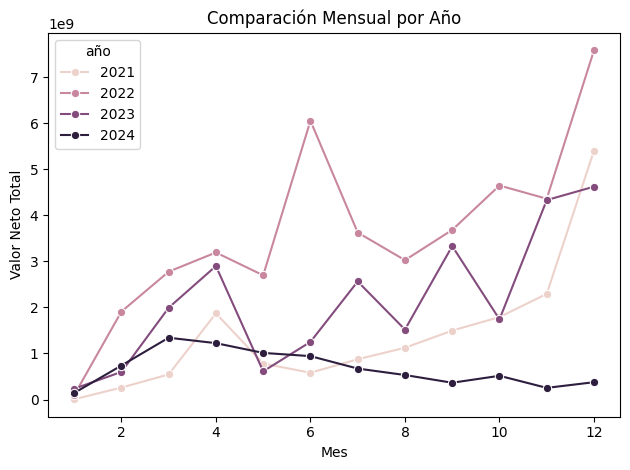

In [939]:
plt.figure()
sns.lineplot(data=giro_mes, x="mes", y="Valor neto total", hue="año", marker="o")

plt.title("Comparación Mensual por Año")
plt.xlabel("Mes")
plt.ylabel("Valor Neto Total")

plt.tight_layout()
plt.show()

In [1053]:
meses_pico = {
    2021: [4, 12],
    2022: [5, 6, 8, 12],
    2023: [4, 7, 9, 12]
}

def detectar_outliers_iqr(data):
    Q1 = data["Valor neto total"].quantile(0.25)
    Q3 = data["Valor neto total"].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    return data[data["Valor neto total"] > limite_superior]

outliers_por_año = (
    giro_mes
    .groupby("año", group_keys=False)
    .apply(detectar_outliers_iqr)
)

def es_mes_pico(row):
    return row["mes"] in meses_pico.get(row["año"], [])

outliers_picos = outliers_por_año[
    outliers_por_año.apply(es_mes_pico, axis=1)
]

C:\Users\DVadeus\AppData\Local\Temp\ipykernel_13292\3326833993.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(detectar_outliers_iqr)


In [1054]:
outliers_picos

,año,mes,Valor neto total
11,2021,12,5406914028
23,2022,12,7584518073


#### ✅ Agregar indices al diccionario de giros

In [940]:
parejas = {
    2021:4,
    2021:12,
    2022:6,
    2022:10,
    2022:12,
    2023:4,
    2023:7,
    2023:9,
    2023:11,
    2023:12
}

for key, value in parejas.items():
    lista = df[(df["año"] == key) & (df["mes"] == value)]["id_unico"]
    for giro in lista:
        giros.update({giro:"Mes con pico de gasto"})


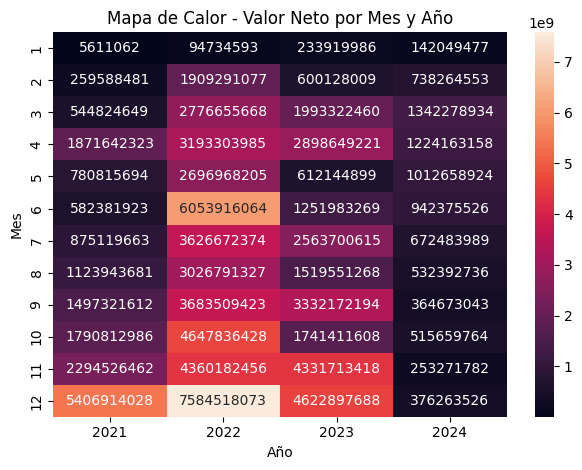

In [941]:
pivot = giro_mes.pivot(index="mes", columns="año", values="Valor neto total")

plt.figure()
sns.heatmap(pivot, annot=True, fmt=".0f")

plt.title("Mapa de Calor - Valor Neto por Mes y Año")
plt.xlabel("Año")
plt.ylabel("Mes")

plt.tight_layout()
plt.show()

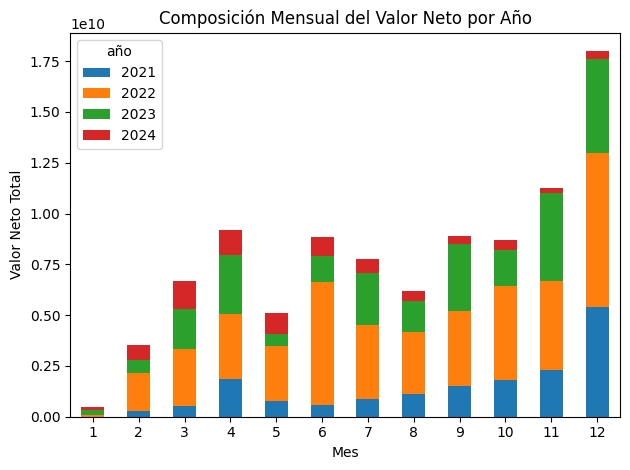

In [942]:
pivot.plot(kind="bar", stacked=True)

plt.title("Composición Mensual del Valor Neto por Año")
plt.xlabel("Mes")
plt.ylabel("Valor Neto Total")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Distribución de montos

Se observan distribuciones muy sesgadas con colas muy largas a la derecha, lo que sugiere pocos pagos muy altos y un alto riesgo de concentración. Esto demuestra giros muy por encima del rango normal. Sugiere realizar una revisión individual a los pagos con estos montos.

Los giros muestran una alta disperción lo que sugiere una falta de control o estandarización.

Se observa un pico para ambas distribuciones en montos pequeños.

#### Histograma de Valor Bruto

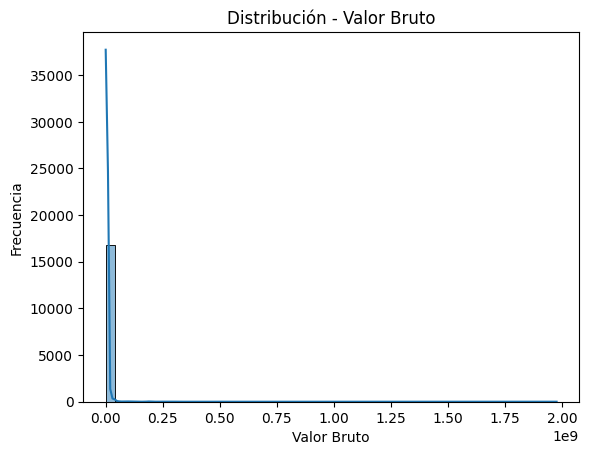

In [943]:
plt.figure()
sns.histplot(data=df, x = "Valor Bruto", bins = 50, kde = True)
plt.title("Distribución - Valor Bruto")
plt.xlabel("Valor Bruto")
plt.ylabel("Frecuencia")
plt.show()

#### Histograma de Valor Neto

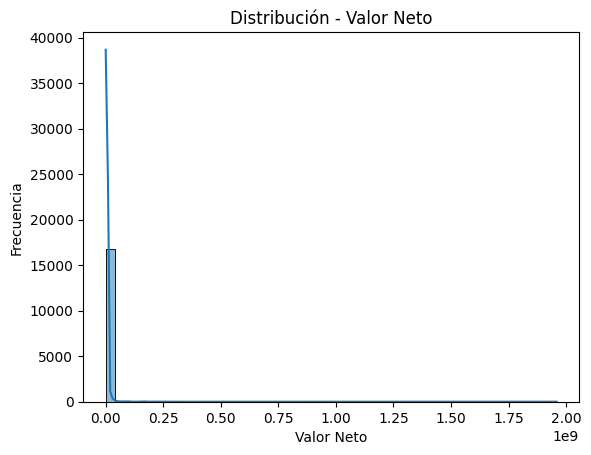

In [944]:
plt.figure()
sns.histplot(data = df, x = "Valor Neto", bins=50, kde=True)

plt.title("Distribución - Valor Neto")
plt.xlabel("Valor Neto")
plt.ylabel("Frecuencia")

plt.show()

#### Boxplot Tipo de Gasto

Se presentan una gran cantidad de valores atípicos en los tipos de gasto ``"Servicios"`` y ``"Contrato"``

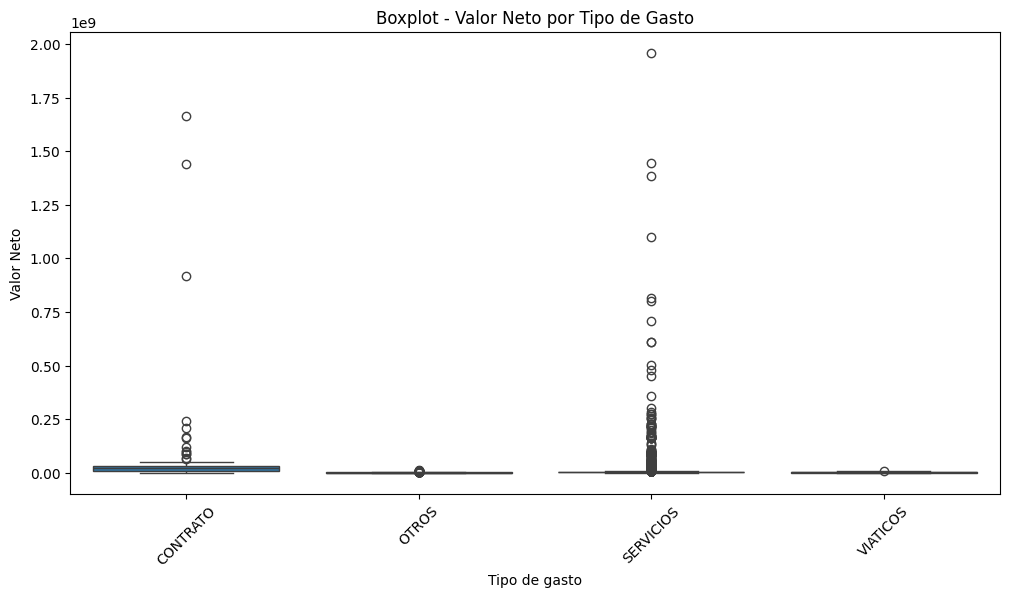

In [945]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x = "Tipo de gasto", y = "Valor Neto")
plt.xticks(rotation=45)
plt.title("Boxplot - Valor Neto por Tipo de Gasto")
plt.xlabel("Tipo de gasto")
plt.ylabel("Valor Neto")

plt.show()

#### Boxplot Banco

Se presentan una gran cantidad de valores atípicos en los bancos ``"Bancolombia"``, ``"BBVA"``, ``"Banco de Occidente"``, ``"Banco de Bogotá"`` y ``"Citibank"``

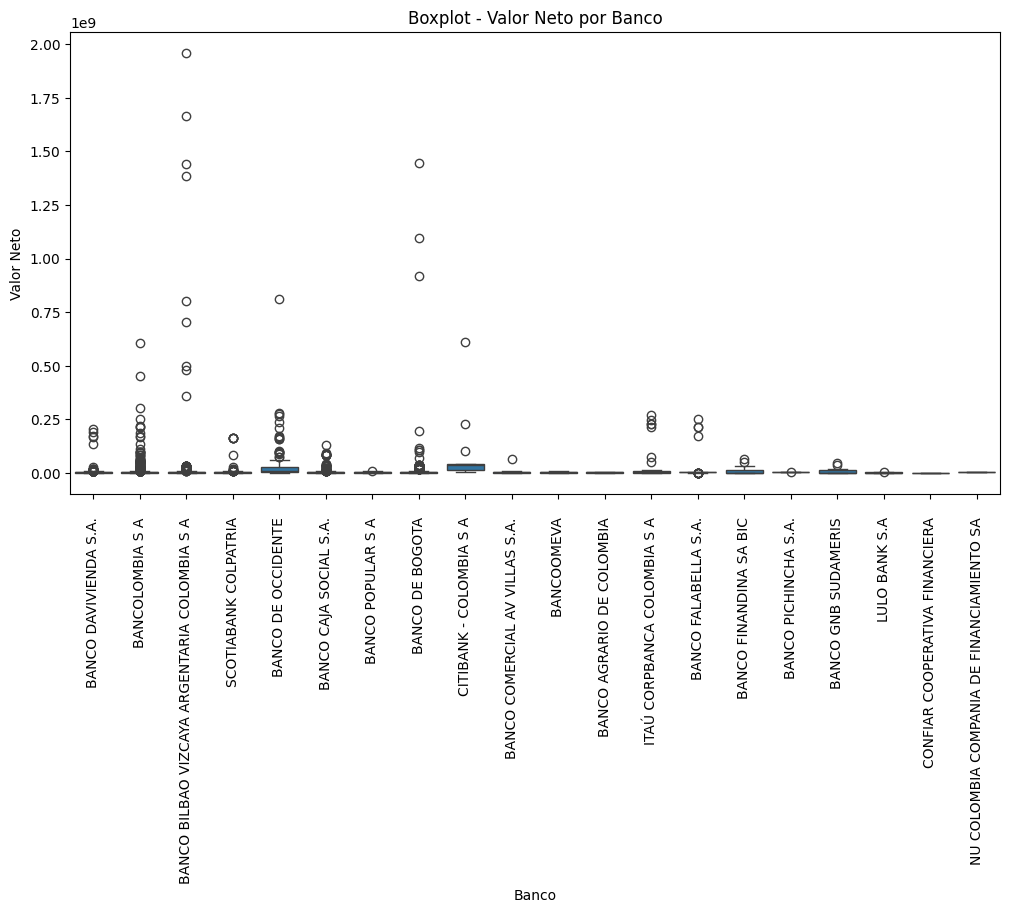

In [946]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Banco", y="Valor Neto")

plt.xticks(rotation=90)
plt.title("Boxplot - Valor Neto por Banco")
plt.xlabel("Banco")
plt.ylabel("Valor Neto")

plt.show()

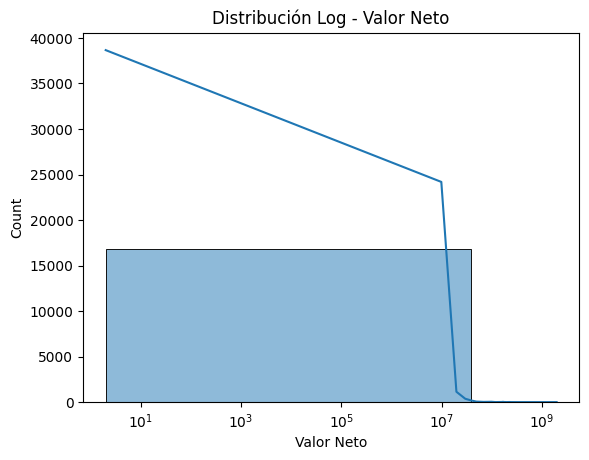

In [947]:
plt.figure()
sns.histplot(data =df, x ="Valor Neto", bins=50, kde=True)

plt.xscale("log")
plt.title("Distribución Log - Valor Neto")

plt.show()

#### Extracción de outliers por banco

Utilizando el método estándar (IQR) mediante:
$$
valor<Q1−1.5∗ IQR \hspace{10pt} \'{o} \hspace{10pt} valor > Q3 + 1.5 ∗ IQR
$$

In [948]:
def detectar_outliers_por_grupo(df, grupo_col, valor_col) -> pd.DataFrame:
    
    outliers_list = []

    for grupo, data in df.groupby(grupo_col):
        
        Q1 = data[valor_col].quantile(0.25)
        Q3 = data[valor_col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[
            (data[valor_col] < lower_bound) | 
            (data[valor_col] > upper_bound)
        ]
        
        outliers_list.append(outliers)

    return pd.concat(outliers_list)

In [949]:
outliers_banco = detectar_outliers_por_grupo(
    df, 
    grupo_col="Banco", 
    valor_col="Valor Neto"
)

outliers_banco

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,ID_Soporte,id_unico,año,mes
512,2021,946,28627633,2021-06-10,8.070398e+08,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,MAGDA CRISTINA MONTAÑA MURILLO,NATURAL,SERVICIOS,2021-04-12,...,232820.0,0.0,1474049.0,12378741,1110,12378741,946,946_28627633_,2021,6
617,2021,1406,28627633,2021-07-09,8.070398e+08,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,MAGDA CRISTINA MONTAÑA MURILLO,NATURAL,SERVICIOS,2021-04-12,...,232820.0,0.0,1355407.0,12497383,1110,12497383,1406,1406_28627633_,2021,7
843,2021,2050,28627633,2021-08-10,8.070398e+08,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,MAGDA CRISTINA MONTAÑA MURILLO,NATURAL,SERVICIOS,2021-04-12,...,232820.0,0.0,1355407.0,12497383,1110,12497383,2050,2050_28627633_,2021,8
1045,2021,2395,28627633,2021-09-02,8.070398e+08,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,MAGDA CRISTINA MONTAÑA MURILLO,NATURAL,SERVICIOS,2021-04-12,...,232820.0,0.0,1355407.0,12497383,1110,12497383,2395,2395_28627633_,2021,9
1508,2021,3402,41520944,2021-10-08,1.381217e+08,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,MARTHA LUCIA FERNANDEZ SARMIENTO,NATURAL,SERVICIOS,2021-05-20,...,689824.0,0.0,5627587.0,35416964,1110,35416964,3402,3402_41520944_,2021,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16547,2024,2399,30332525,2024-08-29,1.003355e+09,SCOTIABANK COLPATRIA,CECILIA CECILIA OCAMPO BOHORQUEZ,NATURAL,SERVICIOS,2024-04-10,...,199924.0,0.0,908751.0,10986729,1110,10986729,2399,2399_30332525_,2024,8
16752,2024,3569,30332525,2024-11-13,1.003355e+09,SCOTIABANK COLPATRIA,CECILIA CECILIA OCAMPO BOHORQUEZ,NATURAL,SERVICIOS,2024-04-10,...,199924.0,0.0,908751.0,10986729,1110,10986729,3569,3569_30332525_,2024,11
16753,2024,3570,30332525,2024-11-13,1.003355e+09,SCOTIABANK COLPATRIA,CECILIA CECILIA OCAMPO BOHORQUEZ,NATURAL,SERVICIOS,2024-04-10,...,199924.0,0.0,908751.0,10986729,1110,10986729,3570,3570_30332525_,2024,11
16820,2024,3969,30332525,2024-12-06,1.003355e+09,SCOTIABANK COLPATRIA,CECILIA CECILIA OCAMPO BOHORQUEZ,NATURAL,SERVICIOS,2024-04-10,...,199924.0,0.0,908751.0,10986729,1110,10986729,3969,3969_30332525_,2024,12


#### ✅ Agregar indices al diccionario de giros

In [950]:
for idx in outliers_banco["id_unico"]:
    giros.update({idx:"Outlier de Valor Neto por Banco"})

#### Extracción de outliers por Tipo de Gasto

In [951]:
outliers_tipo_gasto = detectar_outliers_por_grupo(
    df, 
    grupo_col="Tipo de gasto", 
    valor_col="Valor Neto"
)

outliers_tipo_gasto

C:\Users\DVadeus\AppData\Local\Temp\ipykernel_13292\3447982086.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, data in df.groupby(grupo_col):


,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,ID_Soporte,id_unico,año,mes
3686,2022,7660,900292243,2022-03-17,4.751000e+09,SCOTIABANK COLPATRIA,ISATECH CORPORATION S.A.S,JURIDICA,CONTRATO,2022-01-20,...,3206316.0,0.0,27760281.0,163015503,1110,163015503,7660,7660_900292243_,2022,3
3699,2022,7675,900431030,2022-03-17,8.051631e+08,BANCO COMERCIAL AV VILLAS S.A.,INGENIERIAS Y CONSTRUCCIONES NISSI S.A.S.,JURIDICA,CONTRATO,2022-03-17,...,1299323.0,0.0,11249538.0,66060177,1110,66060177,7675,7675_900431030_,2022,3
3748,2022,7758,830047444,2022-04-13,6.100310e+10,BANCOLOMBIA S A,SERVICIOS ESPECIALIZADOS DE TECNOLOGÍA E INFOR...,JURIDICA,CONTRATO,2022-07-27,...,1774593.0,0.0,2830476.0,85899190,1110,85899190,7758,7758_830047444_,2022,4
3816,2022,7939,830047444,2022-05-23,6.100310e+10,BANCOLOMBIA S A,SERVICIOS ESPECIALIZADOS DE TECNOLOGÍA E INFOR...,JURIDICA,CONTRATO,2022-07-27,...,1784650.0,0.0,2846516.0,86385968,1110,86385968,7939,7939_830047444_,2022,5
4726,2022,1772,830122983,2022-05-24,1.841500e+05,BANCO DE BOGOTA,ESRI COLOMBIA S.A.S,JURIDICA,CONTRATO,2022-03-15,...,19001855.0,0.0,32930215.0,917162557,1110,917162557,1772,1772_830122983_,2022,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16819,2024,3961,45755496,2024-12-06,7.890000e+10,BANCOLOMBIA S A,MARIA CAROLINA CARBALLO GUERRERO,NATURAL,SERVICIOS,2024-01-24,...,273596.0,0.0,1375925.0,12303877,1110,12303877,3961,3961_45755496_,2024,12
16820,2024,3969,30332525,2024-12-06,1.003355e+09,SCOTIABANK COLPATRIA,CECILIA CECILIA OCAMPO BOHORQUEZ,NATURAL,SERVICIOS,2024-04-10,...,199924.0,0.0,908751.0,10986729,1110,10986729,3969,3969_30332525_,2024,12
16824,2024,3983,30332525,2024-12-06,1.003355e+09,SCOTIABANK COLPATRIA,CECILIA CECILIA OCAMPO BOHORQUEZ,NATURAL,SERVICIOS,2024-04-10,...,199924.0,0.0,908751.0,10986729,1110,10986729,3983,3983_30332525_,2024,12
16860,2024,4361,45755496,2024-12-18,7.890000e+10,BANCOLOMBIA S A,MARIA CAROLINA CARBALLO GUERRERO,NATURAL,SERVICIOS,2024-01-24,...,273596.0,0.0,1375925.0,12303877,1110,12303877,4361,4361_45755496_,2024,12


#### ✅ Agregar indices al diccionario de giros

In [952]:
for idx in outliers_tipo_gasto["id_unico"]:
    giros.update({idx:"Outlier de Valor Neto por Tipo de Gasto"})

### Top Actores

Se procede a realizar un análsis de los beneficiarios, para efectos de obtener una mejor distribución de los datos a analizar se dividirá el análisis por ``Tipo de Persona``.

In [953]:
set(df["Tipo de persona"])

{'JURIDICA', 'NATURAL'}

#### Por Beneficiario

🚨 Revisando la concentración de giros por beneficiario se encuentra unos montos considerablemente altos a pocas empresas como a personas naturales, por lo que se realizará un análisis de detección estadística por medio de Z-Score y Feature Engineering

In [954]:
df_juridico = df[df["Tipo de persona"] == "JURIDICA"]

df_natural = df[df["Tipo de persona"] == "NATURAL"]

In [955]:
df_juridico

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,ID_Soporte,id_unico,año,mes
66,2021,3438,800103052,2021-03-12,5.063182e+09,CITIBANK - COLOMBIA S A,ORACLE COLOMBIA LTDA,JURIDICA,SERVICIOS,2021-05-13,...,180099.0,0.0,312112.0,10403795,1110,10403795,3438,3438_800103052_,2021,3
110,2021,3551,800103052,2021-03-23,5.063182e+09,CITIBANK - COLOMBIA S A,ORACLE COLOMBIA LTDA,JURIDICA,SERVICIOS,2021-05-13,...,146624.0,0.0,254099.0,8470012,1110,8470012,3551,3551_800103052_,2021,3
111,2021,3552,860002184,2021-03-23,1.210729e+08,SCOTIABANK COLPATRIA,AXA COLPATRIA SEGUROS S.A.,JURIDICA,SERVICIOS,2021-05-12,...,390425.0,0.0,703546.0,18817706,1110,18817706,3552,3552_860002184_,2021,3
157,2021,3767,800103052,2021-05-21,5.063182e+09,CITIBANK - COLOMBIA S A,ORACLE COLOMBIA LTDA,JURIDICA,SERVICIOS,2021-05-13,...,1751502.0,0.0,3035352.0,101179006,1110,101179006,3767,3767_800103052_,2021,5
158,2021,3785,830505521,2021-05-25,2.910148e+08,BANCO DE OCCIDENTE,SOLUCIONES TECNOLOGIA Y SERVICIOS S.A. STS S.A...,JURIDICA,SERVICIOS,2021-06-23,...,5004807.0,0.0,24563593.0,266862527,1110,266862527,3785,3785_830505521_,2021,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16808,2024,3781,830118348,2024-11-26,4.969998e+09,BANCO DAVIVIENDA S.A.,UNIPAR ALQUILERES DE COMPUTADORES S A,JURIDICA,SERVICIOS,2024-05-30,...,12435.0,0.0,70980.0,668922,1110,668922,3781,3781_830118348_,2024,11
16840,2024,4111,890400048,2024-12-12,5.045013e+10,BANCOLOMBIA S A,ARAUJO & SEGOVIA S.A.,JURIDICA,CONTRATO,2024-03-01,...,463347.0,0.0,2305153.0,25264005,1110,25264005,4111,4111_890400048_,2024,12
16890,2024,4603,901677477,2024-12-27,9.600301e+09,BANCO DAVIVIENDA S.A.,UNION TEMPORAL R&J 2022,JURIDICA,SERVICIOS,2024-04-26,...,10232.0,0.0,45532.0,5679170,1110,5679170,4603,4603_901677477_,2024,12
16891,2024,4604,901677477,2024-12-27,9.600301e+09,BANCO DAVIVIENDA S.A.,UNION TEMPORAL R&J 2022,JURIDICA,SERVICIOS,2024-04-26,...,33124.0,0.0,112772.0,1572018,1110,1572018,4604,4604_901677477_,2024,12


In [956]:
df_natural

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,ID_Soporte,id_unico,año,mes
0,2021,2991,1088259568,2021-02-03,1.272702e+11,BANCO DAVIVIENDA S.A.,YONNY ANDRES CRUZ BENJUMEA,NATURAL,SERVICIOS,2021-04-26,...,37500.0,0.0,63022.0,1499478,1110,1499478,2991,2991_1088259568_,2021,2
1,2021,2992,1088259568,2021-02-03,1.272702e+11,BANCO DAVIVIENDA S.A.,YONNY ANDRES CRUZ BENJUMEA,NATURAL,SERVICIOS,2021-06-21,...,0.0,0.0,0.0,312500,1110,312500,2992,2992_1088259568_,2021,2
2,2021,3001,52539367,2021-02-04,5.700089e+14,BANCO DAVIVIENDA S.A.,ALEXANDRA VARGAS PINILLA,NATURAL,SERVICIOS,2021-05-12,...,156740.0,0.0,546214.0,7290786,1110,7290786,3001,3001_52539367_,2021,2
3,2021,3047,1094938732,2021-02-08,1.202372e+08,BANCOLOMBIA S A,MARIA ALEJANDRA LONDOÑO JIMENEZ,NATURAL,SERVICIOS,2021-06-21,...,30000.0,0.0,52500.0,1447500,1110,1447500,3047,3047_1094938732_,2021,2
4,2021,3053,1093773164,2021-02-08,5.704574e+14,BANCO DAVIVIENDA S.A.,JURGEN DANIEL TOLOZA DELGADO,NATURAL,SERVICIOS,2021-06-03,...,109680.0,0.0,341099.0,6184861,1110,6184861,3053,3053_1093773164_,2021,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16895,2024,4624,1113512793,2024-12-28,8.582164e+10,BANCOLOMBIA S A,MARY YULIANA JARAMILLO,NATURAL,SERVICIOS,2024-02-01,...,138942.0,0.0,189766.0,6757313,1110,6757313,4624,4624_1113512793_,2024,12
16896,2024,4640,1143338180,2024-12-29,7.880001e+10,BANCOLOMBIA S A,YELIZA MERCEDES PEREZ LICONA,NATURAL,SERVICIOS,2024-02-01,...,54033.0,0.0,73423.0,2628219,1110,2628219,4640,4640_1143338180_,2024,12
16897,2024,4641,1047368991,2024-12-29,5.660018e+10,BANCO DAVIVIENDA S.A.,LUISA FERNANDA LARIOS DIAZ,NATURAL,SERVICIOS,2024-01-29,...,54033.0,0.0,74534.0,2627108,1110,2627108,4641,4641_1047368991_,2024,12
16898,2024,4653,64564800,2024-12-30,5.770013e+10,BANCO DAVIVIENDA S.A.,SALMA ELENA CALDAS OTERO,NATURAL,SERVICIOS,2024-02-01,...,0.0,0.0,0.0,2,1110,2,4653,4653_64564800_,2024,12


##### Jurídico

In [957]:
juridico = df_juridico.groupby("Razon_Social")["Valor Neto"].sum().reset_index(name = 'Valor neto total').sort_values(by="Valor neto total", ascending = False)
juridico

,Razon_Social,Valor neto total
35,HQ5 SAS,9297260925
30,ESRI COLOMBIA S.A.S,3523222901
42,QUINTA GENERACIÓN S.A.S,2838962107
13,CHALJUB RESTREPO & CIA S.C.A.,2084653726
7,BUSINESSMIND COLOMBIA S.A.,1579869727
...,...,...
17,COMUNICACION CELULAR S A COMCEL S A,2025046
47,SERVIRED LMA COMUNICACIONES S.A.S.,1180619
0,A Y A RADIOCOMUNICACIONES S.A.S,880000
25,EMPRESA DE ACUEDUCTO Y ALCANTARILLADO DE PEREI...,697020


In [958]:
df_benef_j = df_juridico.groupby("Razon_Social").agg(
    Valor_Neto_Total = ('Valor Neto', 'sum'),
    Cantidad = ('Valor Neto', 'count'),
    Promedio = ('Valor Neto', 'mean')
).sort_values(by = "Valor_Neto_Total", ascending = False)
df_benef_j

,Valor_Neto_Total,Cantidad,Promedio
Razon_Social,,,
HQ5 SAS,9297260925,10,9.297261e+08
ESRI COLOMBIA S.A.S,3523222901,5,7.046446e+08
QUINTA GENERACIÓN S.A.S,2838962107,33,8.602915e+07
CHALJUB RESTREPO & CIA S.C.A.,2084653726,79,2.638802e+07
BUSINESSMIND COLOMBIA S.A.,1579869727,4,3.949674e+08
...,...,...,...
COMUNICACION CELULAR S A COMCEL S A,2025046,28,7.232307e+04
SERVIRED LMA COMUNICACIONES S.A.S.,1180619,4,2.951548e+05
A Y A RADIOCOMUNICACIONES S.A.S,880000,2,4.400000e+05


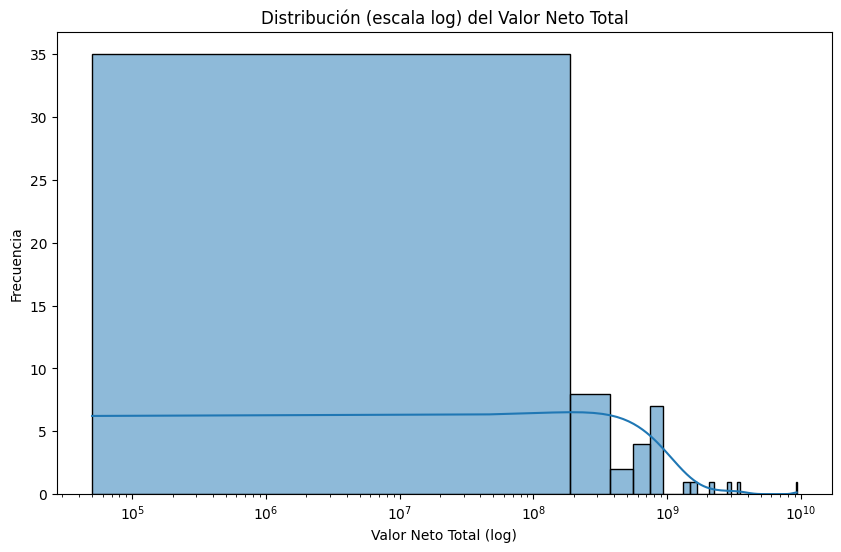

In [959]:
plt.figure(figsize=(10,6))
sns.histplot(data = df_benef_j, x = "Valor_Neto_Total", bins=50, kde=True)
plt.xscale("log")

plt.title("Distribución (escala log) del Valor Neto Total")
plt.xlabel("Valor Neto Total (log)")
plt.ylabel("Frecuencia")

plt.show()

#### ⚠️ Por revisar

Se observa mediante el gráfico de Histógrama en escala logarítmica que la mayoría de los beneficiarios están en valores relativamente bajos. Y que unos pocos beneficiarios concentran montos muy grandes.

Se observa una distribución más extrema que Pareto, posiblemente:

- 5-10 % beneficiarios concentran el 70-90% del dinero

Lo que podría indicar contratistas dominantes o concentración indebida

Además, se encuentran anomalías extremas que llegan incluso a $10^{10}$ 

#### Cálculo del coeficiente de Gini

In [960]:
def gini(array):
    array = np.array(array)
    
    # Evitar negativos o ceros problemáticos
    array = array.flatten()
    array = array[array >= 0]
    
    if np.amin(array) == 0:
        array = array + 1e-9  # evitar división por cero
    
    array = np.sort(array)
    n = len(array)
    
    index = np.arange(1, n + 1)
    
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))

In [961]:
gini_valor = gini(df_benef_j["Valor_Neto_Total"])
print(f"Gini: {gini_valor:.4f}")

Gini: 0.7592


El cálculo del coeficiente de Gini mide la desigualdad de los datos. Siendo:
- 0 = Distribución perfecta de igualdad
- 1 = Máxima desigualdad

Con un resultado de ``0.7592`` se observa una **muy alta concentración de desigualdad**

#### Curva de Lorenz

In [962]:
def curva_lorenz(valores):
    valores = np.sort(valores)
    acumulado = np.cumsum(valores)
    acumulado = np.insert(acumulado, 0, 0)
    acumulado = acumulado / acumulado[-1]
    
    x = np.linspace(0, 1, len(acumulado))
    
    plt.figure(figsize=(6,6))
    plt.plot(x, acumulado, label="Curva de Lorenz")
    plt.plot([0,1], [0,1], linestyle='--', label="Igualdad perfecta")
    
    plt.title("Curva de Lorenz - Distribución de Pagos")
    plt.xlabel("Proporción de beneficiarios")
    plt.ylabel("Proporción del valor acumulado")
    plt.legend()
    
    plt.show()

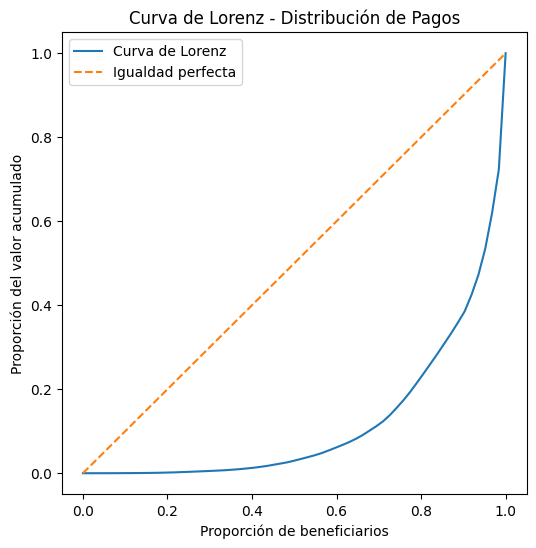

In [963]:
curva_lorenz(df_benef_j["Valor_Neto_Total"])

Según la curva de Lorenz, observamos que la mayoría de los beneficiarios reciben muy poco del total de giros tesorales. Por lo que el dinero se acomula en pocos beneficiarios.

- Cerca del 80% de beneficiarios apenas llegal al 20% del valor Neto Total de los giros
- El 80% restante concentra más del 80% de los giros tesorales.

Por lo tanto, se determina un patrón Pareto muy fuerte.

De ser producto de una concentración indebida podría representar un **riesgo alto**.

#### ⚠️ Por revisar

- Existe una dependencia excesiva en beneficiarios específicos?
- Hay un posible direccionamiento de contratos?
- Hay giros atípicos?
    - Pocos giros de montos muy altos?
    - Muchos giros sistemáticos ?

### Creación de ranking de riesgo por tipo de persona Jurídica

In [964]:
# Variables de riesgo

df_benef_j["log_valor"] = np.log1p(df_benef_j["Valor_Neto_Total"])
df_benef_j["log_cantidad"] = np.log1p(df_benef_j["Cantidad"])
df_benef_j["log_promedio"] = np.log1p(df_benef_j["Promedio"])

In [965]:
# Z-Score
# (Valor - Promedio) / Desviación Estándar

for col in ["log_valor", "log_cantidad", "log_promedio"]:
    df_benef_j[f"z_{col}"] = (df_benef_j[col] - df_benef_j[col].mean()) / df_benef_j[col].std()

In [966]:
# Penalización
# El criterio se basa en que el riesgo es alto cuando:
# - Valor total alto
# - Promedio alto
# - Pocos giros

df_benef_j["riesgo_score"] = (
    0.5 * df_benef_j["z_log_valor"] +
    0.3 * df_benef_j["z_log_promedio"] -
    0.2 * df_benef_j["z_log_cantidad"]  # Se hará penalización por muchos giros
)

In [967]:
# Ranking

df_benef_j.sort_values(by="riesgo_score", ascending=False)

,Valor_Neto_Total,Cantidad,Promedio,log_valor,log_cantidad,log_promedio,z_log_valor,z_log_cantidad,z_log_promedio,riesgo_score
Razon_Social,,,,,,,,,,
HQ5 SAS,9297260925,10,9.297261e+08,22.952986,2.397895,20.650401,1.952660,0.085521,1.824392,1.506543
ESRI COLOMBIA S.A.S,3523222901,5,7.046446e+08,21.982642,1.791759,20.373204,1.547729,-0.492311,1.711597,1.385806
SERVICIOS POSTALES NACIONALES S A,813074946,1,8.130749e+08,20.516334,0.693147,20.516334,0.935828,-1.539625,1.769839,1.306791
UNION TEMPORAL SOFT IG.3,610983628,1,6.109836e+08,20.230581,0.693147,20.230581,0.816582,-1.539625,1.653562,1.212284
BUSINESSMIND COLOMBIA S.A.,1579869727,4,3.949674e+08,21.180608,1.609438,19.794314,1.213035,-0.666120,1.476040,1.182553
...,...,...,...,...,...,...,...,...,...,...
AQUAOCCIDENTE S.A. E.S.P,5230230,34,1.538303e+05,15.469966,3.555348,11.943612,-1.170056,1.188928,-1.718510,-1.338367
E.S.P. EMPRESA DE OBRAS SANITARIAS DE SANTA ROSA DE CABAL - E.I.C.E.,2948646,31,9.511761e+04,14.896857,3.465736,11.462880,-1.409219,1.103500,-1.914126,-1.499547
EMPRESAS PUBLICAS DE ARMENIA E S P,2490290,30,8.300967e+04,14.727910,3.433987,11.326724,-1.479722,1.073234,-1.969529,-1.545366


In [968]:
# Clasificación por niveles

def clasificar_riesgo(score):
    if score > 1.5:
        return "ALTO"
    elif score > 0.5:
        return "MEDIO"
    else:
        return "BAJO"

df_benef_j["nivel_riesgo"] = df_benef_j["riesgo_score"].apply(clasificar_riesgo)

Luego de obtener el indicador de riesgo y el score de riesgo, se procede a extraer los giros del top 5 de ``Tipo de Persona`` jurídica con mayor riesgo

In [969]:
df_riesgo_benef_j = df_benef_j[(df_benef_j["nivel_riesgo"] == "ALTO") | (df_benef_j["nivel_riesgo"] == "MEDIO")].reset_index()

benef_j = df_riesgo_benef_j.sort_values(by="riesgo_score", ascending = False).head(5)
benef_j

,Razon_Social,Valor_Neto_Total,Cantidad,Promedio,log_valor,log_cantidad,log_promedio,z_log_valor,z_log_cantidad,z_log_promedio,riesgo_score,nivel_riesgo
0,HQ5 SAS,9297260925,10,9.297261e+08,22.952986,2.397895,20.650401,1.952660,0.085521,1.824392,1.506543,ALTO
1,ESRI COLOMBIA S.A.S,3523222901,5,7.046446e+08,21.982642,1.791759,20.373204,1.547729,-0.492311,1.711597,1.385806,MEDIO
8,SERVICIOS POSTALES NACIONALES S A,813074946,1,8.130749e+08,20.516334,0.693147,20.516334,0.935828,-1.539625,1.769839,1.306791,MEDIO
12,UNION TEMPORAL SOFT IG.3,610983628,1,6.109836e+08,20.230581,0.693147,20.230581,0.816582,-1.539625,1.653562,1.212284,MEDIO
3,BUSINESSMIND COLOMBIA S.A.,1579869727,4,3.949674e+08,21.180608,1.609438,19.794314,1.213035,-0.666120,1.476040,1.182553,MEDIO


In [970]:
df_giros_juridicos = df[df["Razon_Social"].isin(benef_j["Razon_Social"])]
df_giros_juridicos

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,ID_Soporte,id_unico,año,mes
300,2021,194,830122983,2021-04-15,184150.0,BANCO DE BOGOTA,ESRI COLOMBIA S.A.S,JURIDICA,SERVICIOS,2021-03-13,...,29974958.0,0.0,51946603.0,1446801300,1110,1446801300,194,194_830122983_,2021,4
2706,2021,5698,901023218,2021-12-15,833025943.0,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,HQ5 SAS,JURIDICA,SERVICIOS,2021-09-30,...,645447.0,0.0,3026249.0,359514020,1110,359514020,5698,5698_901023218_,2021,12
3112,2021,6699,901023218,2021-12-27,833025943.0,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,HQ5 SAS,JURIDICA,SERVICIOS,2021-09-30,...,930343.0,0.0,4603248.0,501512968,1110,501512968,6699,6699_901023218_,2021,12
3493,2022,7380,901023218,2022-02-23,833025943.0,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,HQ5 SAS,JURIDICA,SERVICIOS,2022-06-30,...,917189.0,0.0,4140476.0,480890168,1110,480890168,7380,7380_901023218_,2022,2
3685,2022,7658,901023218,2022-03-17,833025943.0,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,HQ5 SAS,JURIDICA,SERVICIOS,2022-06-30,...,1511242.0,0.0,6149367.0,802914548,1110,802914548,7658,7658_901023218_,2022,3
3750,2022,7777,901023218,2022-04-25,833025943.0,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,HQ5 SAS,JURIDICA,SERVICIOS,2022-06-30,...,2670834.0,0.0,10345051.0,1384392008,1110,1384392008,7777,7777_901023218_,2022,4
3825,2022,7962,901023218,2022-06-10,833025943.0,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,HQ5 SAS,JURIDICA,SERVICIOS,2022-06-30,...,3771268.0,0.0,16918980.0,1958420405,1110,1958420405,7962,7962_901023218_,2022,6
3843,2022,8013,901023218,2022-06-16,833025943.0,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,HQ5 SAS,JURIDICA,SERVICIOS,2022-06-30,...,4151156.0,0.0,18533343.0,705892030,1110,705892030,8013,8013_901023218_,2022,6
3896,2022,8226,900062917,2022-10-28,221806300.0,BANCO DE OCCIDENTE,SERVICIOS POSTALES NACIONALES S A,JURIDICA,SERVICIOS,2022-07-08,...,0.0,0.0,0.0,813074946,1110,813074946,8226,8226_900062917_,2022,10
4726,2022,1772,830122983,2022-05-24,184150.0,BANCO DE BOGOTA,ESRI COLOMBIA S.A.S,JURIDICA,CONTRATO,2022-03-15,...,19001855.0,0.0,32930215.0,917162557,1110,917162557,1772,1772_830122983_,2022,5


#### ✅ Agregar indices al diccionario de giros

In [971]:
for idx in df_giros_juridicos["id_unico"]:
    giros.update({idx:"Riesgo alto: Persona Jurídica"})

##### Natural

In [972]:
natural = df_natural.groupby("Razon_Social")["Valor Neto"].sum().reset_index(name = 'Valor neto total').sort_values(by="Valor neto total", ascending = False)
natural

,Razon_Social,Valor neto total
679,JORGE ELIECER GAITAN TORRES,1149730864
288,DAGOBERTO ROBAYO GUTIERREZ,858307540
994,MARIA GLADIS OCAMPO,699873493
948,MAGDA CRISTINA MONTAÑA MURILLO,377350146
421,EDWUARD ANDRES REYES ALVARADO,327545567
...,...,...
648,JOHANNA CAROLINA MENDOZA BRAND,680816
1097,NATALIA SANCHEZ MORALES,644035
339,DAVID GUSTAVO RODRIGUEZ MEDINA,518438
831,LAURA CAROLINA DIAZ BARRIOS,375000


In [973]:
df_benef_n = df_natural.groupby("Razon_Social").agg(
    Valor_Neto_Total = ('Valor Neto', 'sum'),
    Cantidad = ('Valor Neto', 'count'),
    Promedio = ('Valor Neto', 'mean')
).sort_values(by = "Valor_Neto_Total", ascending = False)
df_benef_n

,Valor_Neto_Total,Cantidad,Promedio
Razon_Social,,,
JORGE ELIECER GAITAN TORRES,1149730864,9,1.277479e+08
DAGOBERTO ROBAYO GUTIERREZ,858307540,4,2.145769e+08
MARIA GLADIS OCAMPO,699873493,61,1.147334e+07
MAGDA CRISTINA MONTAÑA MURILLO,377350146,35,1.078143e+07
EDWUARD ANDRES REYES ALVARADO,327545567,55,5.955374e+06
...,...,...,...
JOHANNA CAROLINA MENDOZA BRAND,680816,1,6.808160e+05
NATALIA SANCHEZ MORALES,644035,1,6.440350e+05
DAVID GUSTAVO RODRIGUEZ MEDINA,518438,2,2.592190e+05


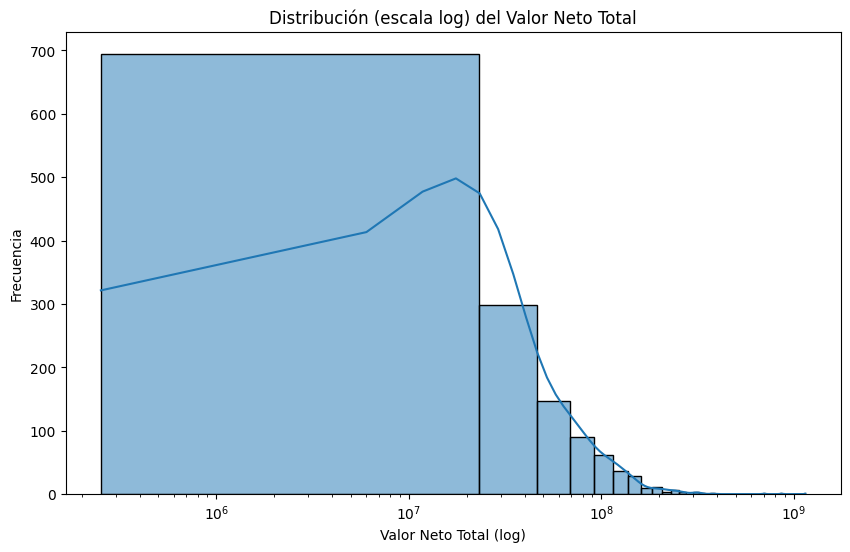

In [974]:
plt.figure(figsize=(10,6))
sns.histplot(data = df_benef_n, x = "Valor_Neto_Total", bins=50, kde=True)
plt.xscale("log")

plt.title("Distribución (escala log) del Valor Neto Total")
plt.xlabel("Valor Neto Total (log)")
plt.ylabel("Frecuencia")

plt.show()

#### ⚠️ Por revisar

Al igual que en histograma en escala logarítmica del Valor Neto Total por el tipo de persona Jurídica, en este caso se observa un comportamiento similar. La mayoría de los beneficiarios están en valores relativamente bajos. Y unos pocos beneficiarios concentran montos muy grandes en órdenes de magnitud. Además la curva KDE no es simétrica por lo que invalidad cualquier tipo de estadística clásica.

#### Cálculo del coeficiente de Gini

In [975]:
gini_valor = gini(df_benef_n["Valor_Neto_Total"])
print(f"Gini: {gini_valor:.4f}")

Gini: 0.5447


El cálculo del coeficiente de Gini mide la desigualdad de los datos. Siendo:
- 0 = Distribución perfecta de igualdad
- 1 = Máxima desigualdad

Con un resultado de ``0.5447`` se observa una **concentración moderada de desigualdad**

#### Curva de Lorenz

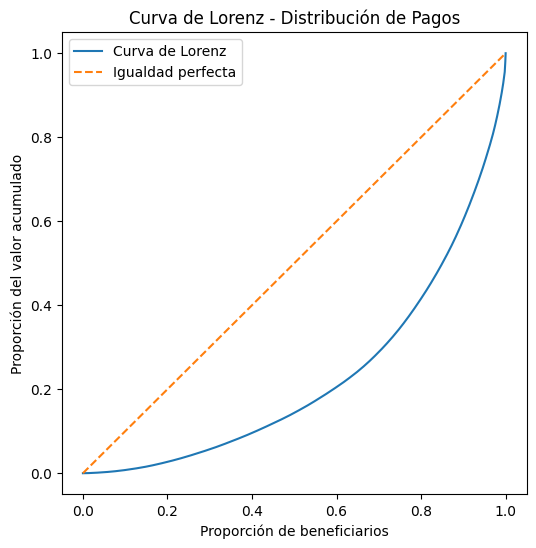

In [976]:
curva_lorenz(df_benef_n["Valor_Neto_Total"])

La curva de Lorenz evidencia una alta concentración del Valor Neto Total en un porcentaje reducido de beneficiarios de tipo natural, indicando una distribución desigual de los recursos. Este comportamiento sugiere riesgos potenciales asociados a concentración de pagos, dependencia de actores específicos y posibles anomalías que requieren análisis detallado en los beneficiarios de mayor participación.

#### ⚠️ Por revisar

- Existe una dependencia excesiva en beneficiarios específicos?
- Hay un posible direccionamiento de contratos?
- Hay giros atípicos?
    - Pocos giros de montos muy altos?
    - Muchos giros sistemáticos ?

### Creación de ranking de riesgo por tipo de persona Jurídica

In [977]:
# Variables de riesgo

df_benef_n["log_valor"] = np.log1p(df_benef_n["Valor_Neto_Total"])
df_benef_n["log_cantidad"] = np.log1p(df_benef_n["Cantidad"])
df_benef_n["log_promedio"] = np.log1p(df_benef_n["Promedio"])

In [978]:
# Z-Score
# (Valor - Promedio) / Desviación Estándar

for col in ["log_valor", "log_cantidad", "log_promedio"]:
    df_benef_n[f"z_{col}"] = (df_benef_n[col] - df_benef_n[col].mean()) / df_benef_n[col].std()

In [979]:
# Penalización
# El criterio se basa en que el riesgo es alto cuando:
# - Valor total alto
# - Promedio alto
# - Pocos giros

df_benef_n["riesgo_score"] = (
    0.5 * df_benef_n["z_log_valor"] +
    0.3 * df_benef_n["z_log_promedio"] -
    0.2 * df_benef_n["z_log_cantidad"]  # Se hará penalización por muchos giros
)

In [980]:
# Ranking

df_benef_n.sort_values(by="riesgo_score", ascending=False)

,Valor_Neto_Total,Cantidad,Promedio,log_valor,log_cantidad,log_promedio,z_log_valor,z_log_cantidad,z_log_promedio,riesgo_score
Razon_Social,,,,,,,,,,
DAGOBERTO ROBAYO GUTIERREZ,858307540,4,2.145769e+08,20.570473,1.609438,19.184179,3.182719,-0.822990,7.929288,4.134744
JORGE ELIECER GAITAN TORRES,1149730864,9,1.277479e+08,20.862794,2.302585,18.665569,3.443792,0.093069,6.961120,3.791619
MARTHA LUCIA FERNANDEZ SARMIENTO,194673106,10,1.946731e+07,19.086832,2.397895,16.784247,1.857669,0.219030,3.448971,1.919720
MARIA GLADIS OCAMPO,699873493,61,1.147334e+07,20.366410,4.127134,16.255536,3.000469,2.504382,2.461947,1.737942
MAGDA CRISTINA MONTAÑA MURILLO,377350146,35,1.078143e+07,19.748684,3.583519,16.193336,2.448773,1.785943,2.345828,1.570946
...,...,...,...,...,...,...,...,...,...,...
LUIS ORLANDO BARRERA CEPEDA,1903817,5,3.807634e+05,14.459372,1.791759,12.849936,-2.275148,-0.582035,-3.895804,-2.189908
JUAN CARLOS LOZANO MUNEVAR,9873760,57,1.732239e+05,16.105391,4.060443,12.062346,-0.805077,2.416243,-5.366119,-2.495622
LAURA CAROLINA DIAZ BARRIOS,375000,1,3.750000e+05,12.834684,0.693147,12.834684,-3.726168,-2.033954,-3.924278,-2.633576


In [981]:
# Clasificación por niveles

def clasificar_riesgo(score):
    if score > 1.5:
        return "ALTO"
    elif score > 0.5:
        return "MEDIO"
    else:
        return "BAJO"

df_benef_n["nivel_riesgo"] = df_benef_n["riesgo_score"].apply(clasificar_riesgo)

Luego de obtener el indicador de riesgo y el score de riesgo, se procede a extraer los giros del top 50 de ``Tipo de Persona`` natural con mayor riesgo

In [982]:
df_riesgo_benef_n = df_benef_n[(df_benef_n["nivel_riesgo"] == "ALTO") | (df_benef_n["nivel_riesgo"] == "MEDIO")].reset_index()

benef_n = df_riesgo_benef_n.sort_values(by="riesgo_score", ascending = False).head(50)
benef_n

,Razon_Social,Valor_Neto_Total,Cantidad,Promedio,log_valor,log_cantidad,log_promedio,z_log_valor,z_log_cantidad,z_log_promedio,riesgo_score,nivel_riesgo
1,DAGOBERTO ROBAYO GUTIERREZ,858307540,4,2.145769e+08,20.570473,1.609438,19.184179,3.182719,-0.822990,7.929288,4.134744,ALTO
0,JORGE ELIECER GAITAN TORRES,1149730864,9,1.277479e+08,20.862794,2.302585,18.665569,3.443792,0.093069,6.961120,3.791619,ALTO
31,MARTHA LUCIA FERNANDEZ SARMIENTO,194673106,10,1.946731e+07,19.086832,2.397895,16.784247,1.857669,0.219030,3.448971,1.919720,ALTO
2,MARIA GLADIS OCAMPO,699873493,61,1.147334e+07,20.366410,4.127134,16.255536,3.000469,2.504382,2.461947,1.737942,ALTO
3,MAGDA CRISTINA MONTAÑA MURILLO,377350146,35,1.078143e+07,19.748684,3.583519,16.193336,2.448773,1.785943,2.345828,1.570946,ALTO
198,HUGO PHERNEY SOTELO YAGAMA,64447732,4,1.611193e+07,17.981365,1.609438,16.595071,0.870369,-0.822990,3.095807,1.528524,ALTO
18,LUIS MARTIN LEGUIZAMON CEPEDA,234956961,22,1.067986e+07,19.274913,3.135494,16.183871,2.025645,1.193836,2.328157,1.472502,MEDIO
73,XIMENA PIEDAD AGUILLON MAYORGA,135478204,12,1.128985e+07,18.724321,2.564949,16.239415,1.533908,0.439808,2.431850,1.408547,MEDIO
59,SUSAN MILENA BUITRAGO MONDRAGON,144001938,14,1.028585e+07,18.785337,2.708050,16.146280,1.588402,0.628929,2.257981,1.345809,MEDIO
60,JOHN GUIBSSON GARCIA GUERRERO,143062205,14,1.021873e+07,18.778790,2.708050,16.139733,1.582554,0.628929,2.245759,1.339219,MEDIO


In [983]:
df_giros_naturales = df[df["Razon_Social"].isin(benef_n["Razon_Social"])]
df_giros_naturales

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,ID_Soporte,id_unico,año,mes
49,2021,3114,79864985,2021-02-11,6.952968e+10,BANCOLOMBIA S A,EDWUARD ANDRES REYES ALVARADO,NATURAL,SERVICIOS,2021-06-17,...,76667.0,0.0,103501.0,3729832,1110,3729832,3114,3114_79864985_,2021,2
62,2021,3343,2994549,2021-03-03,5.500062e+14,BANCO DAVIVIENDA S.A.,JAIME BONILLA GODOY,NATURAL,SERVICIOS,2021-06-11,...,62087.0,0.0,196070.0,3498086,1110,3498086,3343,3343_2994549_,2021,3
63,2021,3344,2994549,2021-03-03,5.500062e+14,BANCO DAVIVIENDA S.A.,JAIME BONILLA GODOY,NATURAL,SERVICIOS,2021-06-11,...,186260.0,0.0,1076141.0,10006329,1110,10006329,3344,3344_2994549_,2021,3
107,2021,3548,79864985,2021-03-23,6.952968e+10,BANCOLOMBIA S A,EDWUARD ANDRES REYES ALVARADO,NATURAL,SERVICIOS,2021-06-17,...,100000.0,0.0,134126.0,4865874,1110,4865874,3548,3548_79864985_,2021,3
121,2021,3591,79864985,2021-04-14,6.952968e+10,BANCOLOMBIA S A,EDWUARD ANDRES REYES ALVARADO,NATURAL,SERVICIOS,2021-06-17,...,100000.0,0.0,133860.0,4866140,1110,4866140,3591,3591_79864985_,2021,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16820,2024,3969,30332525,2024-12-06,1.003355e+09,SCOTIABANK COLPATRIA,CECILIA CECILIA OCAMPO BOHORQUEZ,NATURAL,SERVICIOS,2024-04-10,...,199924.0,0.0,908751.0,10986729,1110,10986729,3969,3969_30332525_,2024,12
16824,2024,3983,30332525,2024-12-06,1.003355e+09,SCOTIABANK COLPATRIA,CECILIA CECILIA OCAMPO BOHORQUEZ,NATURAL,SERVICIOS,2024-04-10,...,199924.0,0.0,908751.0,10986729,1110,10986729,3983,3983_30332525_,2024,12
16826,2024,4017,1113512793,2024-12-09,8.582164e+10,BANCOLOMBIA S A,MARY YULIANA JARAMILLO,NATURAL,SERVICIOS,2024-02-01,...,138942.0,0.0,192142.0,6754937,1110,6754937,4017,4017_1113512793_,2024,12
16860,2024,4361,45755496,2024-12-18,7.890000e+10,BANCOLOMBIA S A,MARIA CAROLINA CARBALLO GUERRERO,NATURAL,SERVICIOS,2024-01-24,...,273596.0,0.0,1375925.0,12303877,1110,12303877,4361,4361_45755496_,2024,12


#### ✅ Agregar indices al diccionario de giros

In [984]:
for idx in df_giros_naturales["id_unico"]:
    giros.update({idx:"Riesgo alto: Persona Natural"})

#### Por Banco

In [985]:
banco_valor_total = df.groupby("Banco")["Valor Neto"].sum().reset_index(name = 'Valor neto total').sort_values(by="Valor neto total", ascending = False)
banco_valor_total

,Banco,Valor neto total
12,BANCOLOMBIA S A,28250881781
4,BANCO DAVIVIENDA S.A.,19864809973
1,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,13417017537
5,BANCO DE BOGOTA,8960995770
2,BANCO CAJA SOCIAL S.A.,6996568847
19,SCOTIABANK COLPATRIA,5217461687
6,BANCO DE OCCIDENTE,5175643061
16,ITAÚ CORPBANCA COLOMBIA S A,1733616690
14,CITIBANK - COLOMBIA S A,1185508563
7,BANCO FALABELLA S.A.,1118739882


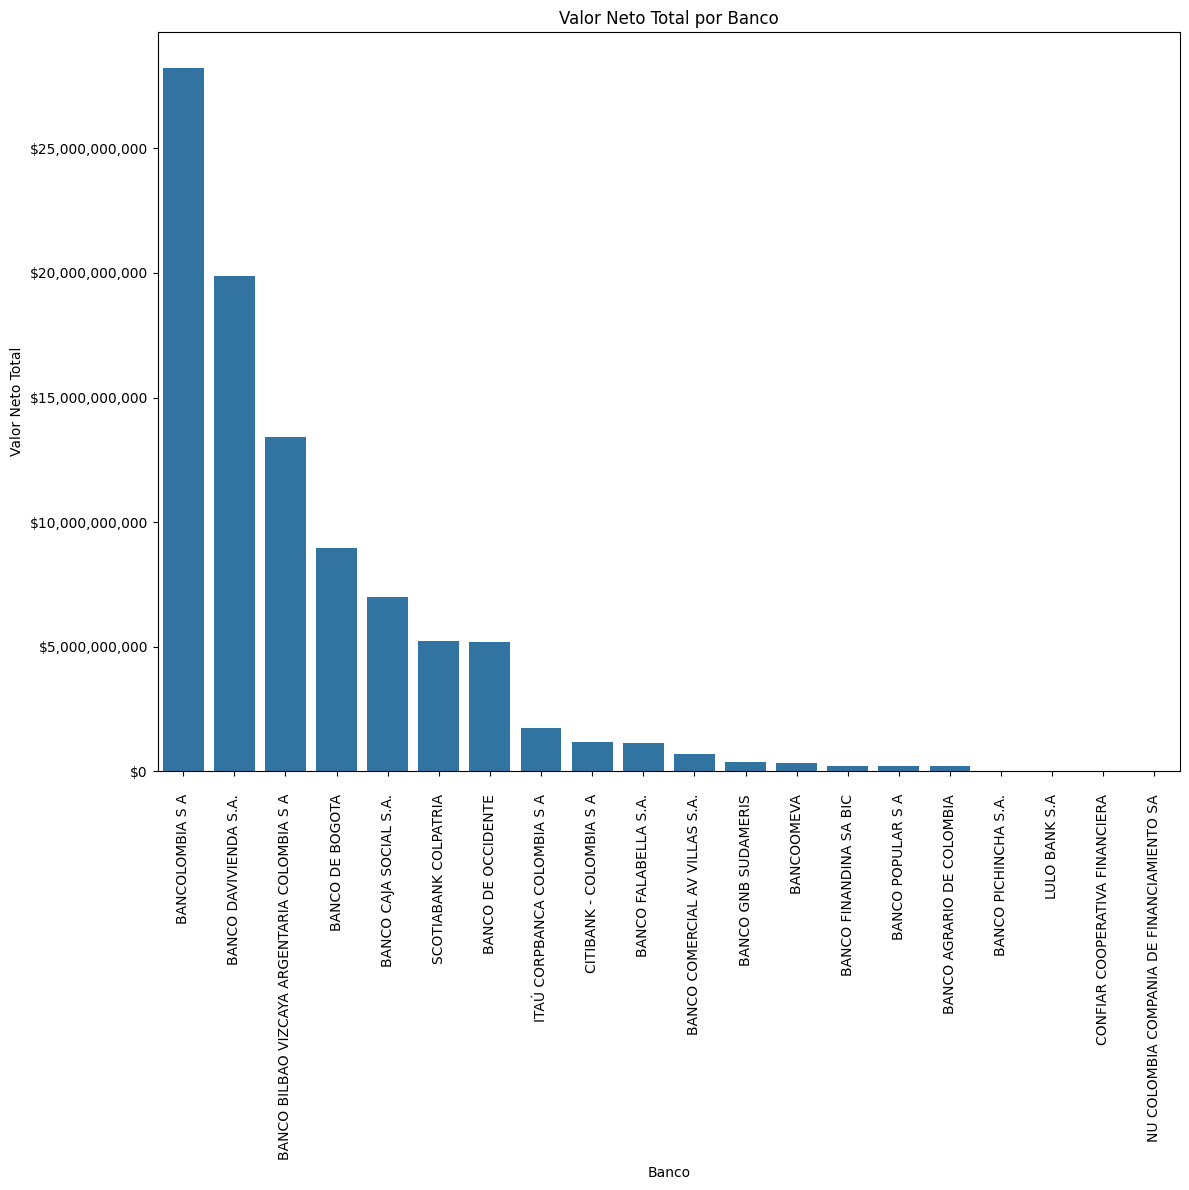

In [986]:
plt.figure(figsize=(12,12))
ax = sns.barplot(data=banco_valor_total, x="Banco", y="Valor neto total")

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.title("Valor Neto Total por Banco")
plt.xlabel("Banco")
plt.ylabel("Valor Neto Total")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Verificación de columnas duplicadas

Se verifica si las características ``"Número de orden de pago"`` y `"ID_Soporte"` tienen exactamente los mismos datos.

In [987]:
df["Número de orden de pago"].equals(df["ID_Soporte"])

True

Al ser verdad. Se procede a eliminar la columna duplicada: `"ID_Soporte"`

In [988]:
df.drop(columns = ["ID_Soporte"], inplace = True)

#### Verificación de ``Número de orden de pago``

Verificar si ``Número de orden de pago`` es único para cada giro tesoral

In [989]:
df["Número de orden de pago"].is_unique

False

Debido a que no son únicos, se procede a evaluar el impacto:

In [990]:
duplicados_orden_pago_primero = df[df.duplicated(subset=["Número de orden de pago"], keep = "first")]
duplicados_orden_pago_primero

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Estampilla Universidad FJC,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,id_unico,año,mes
1330,2021,2991,42117501,2021-09-20,3.218515e+09,BANCOLOMBIA S A,PAULA ANDREA GOMEZ PEREZ,NATURAL,SERVICIOS,2021-07-28,...,0.0,43333.0,0.0,75833.0,2090834,1110,2090834,2991_42117501_,2021,9
1331,2021,2992,1088303250,2021-09-20,1.802027e+09,SCOTIABANK COLPATRIA,JOHN ALEJANDRO GARCIA CASTAÑO,NATURAL,SERVICIOS,2021-07-27,...,0.0,49000.0,0.0,85750.0,2364250,1110,2364250,2992_1088303250_,2021,9
1340,2021,3001,18513430,2021-09-20,5.504884e+14,BANCO DAVIVIENDA S.A.,HUBERNEY JARAMILLO OSORIO,NATURAL,SERVICIOS,2021-07-30,...,0.0,49000.0,0.0,85750.0,2364250,1110,2364250,3001_18513430_,2021,9
1379,2021,3053,10032846,2021-09-24,2.406949e+10,BANCO CAJA SOCIAL S.A.,HECTOR FABIO ARIAS PULGARIN,NATURAL,SERVICIOS,2021-07-19,...,0.0,11667.0,0.0,20417.0,562916,1110,562916,3053_10032846_,2021,9
1390,2021,3065,52469447,2021-09-24,2.219497e+10,BANCOLOMBIA S A,MARIA ANDREA ROZO MEDINA,NATURAL,VIATICOS,2021-09-23,...,0.0,0.0,0.0,0.0,636010,1110,636010,3065_52469447_,2021,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16895,2024,4624,1113512793,2024-12-28,8.582164e+10,BANCOLOMBIA S A,MARY YULIANA JARAMILLO,NATURAL,SERVICIOS,2024-02-01,...,0.0,138942.0,0.0,189766.0,6757313,1110,6757313,4624_1113512793_,2024,12
16896,2024,4640,1143338180,2024-12-29,7.880001e+10,BANCOLOMBIA S A,YELIZA MERCEDES PEREZ LICONA,NATURAL,SERVICIOS,2024-02-01,...,0.0,54033.0,0.0,73423.0,2628219,1110,2628219,4640_1143338180_,2024,12
16897,2024,4641,1047368991,2024-12-29,5.660018e+10,BANCO DAVIVIENDA S.A.,LUISA FERNANDA LARIOS DIAZ,NATURAL,SERVICIOS,2024-01-29,...,0.0,54033.0,0.0,74534.0,2627108,1110,2627108,4641_1047368991_,2024,12
16898,2024,4653,64564800,2024-12-30,5.770013e+10,BANCO DAVIVIENDA S.A.,SALMA ELENA CALDAS OTERO,NATURAL,SERVICIOS,2024-02-01,...,0.0,0.0,0.0,0.0,2,1110,2,4653_64564800_,2024,12


In [991]:
duplicados_orden_pago = df[df.duplicated(subset=["Número de orden de pago"], keep = False)]
duplicados_orden_pago

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Estampilla Universidad FJC,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,id_unico,año,mes
0,2021,2991,1088259568,2021-02-03,1.272702e+11,BANCO DAVIVIENDA S.A.,YONNY ANDRES CRUZ BENJUMEA,NATURAL,SERVICIOS,2021-04-26,...,0.0,37500.0,0.0,63022.0,1499478,1110,1499478,2991_1088259568_,2021,2
1,2021,2992,1088259568,2021-02-03,1.272702e+11,BANCO DAVIVIENDA S.A.,YONNY ANDRES CRUZ BENJUMEA,NATURAL,SERVICIOS,2021-06-21,...,0.0,0.0,0.0,0.0,312500,1110,312500,2992_1088259568_,2021,2
2,2021,3001,52539367,2021-02-04,5.700089e+14,BANCO DAVIVIENDA S.A.,ALEXANDRA VARGAS PINILLA,NATURAL,SERVICIOS,2021-05-12,...,0.0,156740.0,0.0,546214.0,7290786,1110,7290786,3001_52539367_,2021,2
3,2021,3047,1094938732,2021-02-08,1.202372e+08,BANCOLOMBIA S A,MARIA ALEJANDRA LONDOÑO JIMENEZ,NATURAL,SERVICIOS,2021-06-21,...,0.0,30000.0,0.0,52500.0,1447500,1110,1447500,3047_1094938732_,2021,2
4,2021,3053,1093773164,2021-02-08,5.704574e+14,BANCO DAVIVIENDA S.A.,JURGEN DANIEL TOLOZA DELGADO,NATURAL,SERVICIOS,2021-06-03,...,0.0,109680.0,0.0,341099.0,6184861,1110,6184861,3053_1093773164_,2021,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16895,2024,4624,1113512793,2024-12-28,8.582164e+10,BANCOLOMBIA S A,MARY YULIANA JARAMILLO,NATURAL,SERVICIOS,2024-02-01,...,0.0,138942.0,0.0,189766.0,6757313,1110,6757313,4624_1113512793_,2024,12
16896,2024,4640,1143338180,2024-12-29,7.880001e+10,BANCOLOMBIA S A,YELIZA MERCEDES PEREZ LICONA,NATURAL,SERVICIOS,2024-02-01,...,0.0,54033.0,0.0,73423.0,2628219,1110,2628219,4640_1143338180_,2024,12
16897,2024,4641,1047368991,2024-12-29,5.660018e+10,BANCO DAVIVIENDA S.A.,LUISA FERNANDA LARIOS DIAZ,NATURAL,SERVICIOS,2024-01-29,...,0.0,54033.0,0.0,74534.0,2627108,1110,2627108,4641_1047368991_,2024,12
16898,2024,4653,64564800,2024-12-30,5.770013e+10,BANCO DAVIVIENDA S.A.,SALMA ELENA CALDAS OTERO,NATURAL,SERVICIOS,2024-02-01,...,0.0,0.0,0.0,0.0,2,1110,2,4653_64564800_,2024,12


Existen ``11.883`` giros con órdenes de pago iguales. De estos aparecen una única vez `6.708`.
Obteniendo un impacto en la característica ``órdenes de pago`` de:

In [992]:
print("Impacto del:{0:8.2f}%".format((len(duplicados_orden_pago) - len(duplicados_orden_pago_primero))/len(df)* 100))

Impacto del:   30.62%


#### ⚠️ Por revisar

Se ha identificado que el 30.62% de los registros presentan repetición en el número de orden de pago. Esta situación podría obedecer a la existencia de múltiples giros asociados a una misma orden, sin embargo, se requiere validar la consistencia de estos registros para descartar duplicidades indebidas o errores en el procesamiento.

#### 🧠 Pregunta

**Una órden de pago puede tener varios giros tesorales?**

#### 🧠 Pregunta

Cuántos giros tiene cada orden?

El máximo número de órdenes por giro es de 5.

In [993]:
conteo_orden = df.groupby("Número de orden de pago").size()
conteo_orden.describe()

count    10192.000000
mean         1.658163
std          0.750563
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          5.000000
dtype: float64

In [994]:
ordenes_sospechosas = conteo_orden[conteo_orden > 3]
ordenes_sospechosas.sort_values(ascending=False)

Número de orden de pago
3092    5
17      4
18      4
20      4
13      4
       ..
4480    4
4521    4
4524    4
4605    4
4640    4
Length: 189, dtype: int64

Se hace revisión de la órden de pago número 3092, y se encuentra que esta órden fue usada para giros efectuados en fechas diferentes.

In [995]:
df[df["Número de orden de pago"] == 3092]

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Estampilla Universidad FJC,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,id_unico,año,mes
28,2021,3092,1131185598,2021-02-10,4.510993e+08,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,MARLEN CECILIA RUIZ MOSQUERA,NATURAL,SERVICIOS,2021-04-30,...,0.0,37500.0,0.0,63085.0,1811915,1110,1811915,3092_1131185598_,2021,2
1404,2021,3092,1024497533,2021-10-04,6.186965e+10,BANCOLOMBIA S A,HECTOR LEONARDO ARIAS GARCIA,NATURAL,SERVICIOS,2021-03-11,...,0.0,129140.0,0.0,330216.0,6126784,1110,6126784,3092_1024497533_,2021,10
5228,2022,3092,79046541,2022-07-07,5.504884e+14,BANCO DAVIVIENDA S.A.,SEGUNDO FIDEL PUERTO GARAVITO,NATURAL,SERVICIOS,2022-01-28,...,0.0,149640.0,0.0,494270.0,6987730,1110,6987730,3092_79046541_,2022,7
12360,2023,3092,1013624954,2023-07-05,5.504884e+14,BANCO DAVIVIENDA S.A.,MICHAEL STIVENS VILLAMIL QUINTERO,NATURAL,SERVICIOS,2023-01-06,...,0.0,65340.0,0.0,103847.0,3163153,1110,3163153,3092_1013624954_,2023,7
16657,2024,3092,1007313801,2024-10-13,6.782480e+10,BANCOLOMBIA S A,CLARIBETH DEL CARMEN ALVAREZ CORTES,NATURAL,SERVICIOS,2024-01-30,...,0.0,54033.0,0.0,74534.0,2627108,1110,2627108,3092_1007313801_,2024,10


In [996]:
df[df["Número de orden de pago"] == 17]

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Estampilla Universidad FJC,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,id_unico,año,mes
166,2021,17,80410647,2021-02-05,4.070115e+09,BANCO DAVIVIENDA S.A.,JAVIER RICARDO RINCON RUEDA,NATURAL,SERVICIOS,2021-02-05,...,0.0,0.0,0.0,0.0,2851233,1110,2851233,17_80410647_,2021,2
3928,2022,17,800052640,2022-01-21,NaN,NaN,EMPRESA DE ENERGIA DEL QUINDIO S.A. E.S.P. EMP...,JURIDICA,SERVICIOS,2022-01-21,...,0.0,0.0,0.0,0.0,500609,1110,500609,17_800052640_,2022,1
10979,2023,17,800052640,2023-01-30,NaN,NaN,EMPRESA DE ENERGIA DEL QUINDIO S.A. E.S.P. EMP...,JURIDICA,SERVICIOS,2023-01-23,...,0.0,0.0,0.0,0.0,550062,1110,550062,17_800052640_,2023,1
15522,2024,17,800249860,2024-01-25,NaN,NaN,CELSIA COLOMBIA S.A E.S.P,JURIDICA,SERVICIOS,2024-01-24,...,0.0,0.0,0.0,0.0,3540667,1110,3540667,17_800249860_,2024,1


#### ⚠️ Por revisar

Se ha identificado que los números de órden de pago contienen varios giros tesorales en fechas separadas por años de diferencia. Lo que sugiere una posible reutilización o una mala gestión del identificador. Debe verificarse si el identificador ``"Número de orden de pago"`` no es único e identifica a un documento base reutilizable, lote o un proceso en específico.

In [997]:
df.groupby("Número de orden de pago")["Razon_Social"].nunique().sort_values(ascending=False)

Número de orden de pago
3092     5
2699     4
146      4
179      4
1175     4
        ..
12801    1
12791    1
12790    1
12788    1
12786    1
Name: Razon_Social, Length: 10192, dtype: int64

#### ⚠️ Por revisar

Se encuentran diferencias de más de 3 años en 233 números de órden de pago.

In [998]:
res = df.groupby(["Número de orden de pago"])["Fecha Giro"].agg(["min", "max"])
res["dias_diferencia"] = (res["max"] - res["min"]).dt.days

In [999]:
res[res["dias_diferencia"] > 1095].sort_values(by = "dias_diferencia", ascending = False)

,min,max,dias_diferencia
Número de orden de pago,,,
3269,2021-02-22,2024-10-30,1346
3113,2021-02-10,2024-10-16,1344
3110,2021-02-10,2024-10-16,1344
3111,2021-02-10,2024-10-16,1344
3112,2021-02-10,2024-10-16,1344
...,...,...,...
2212,2021-08-13,2024-08-14,1097
2153,2021-08-12,2024-08-12,1096
2189,2021-08-13,2024-08-13,1096


Siendo el ``Número de órden de pago`` **3269** el que más diferencias de días tiene

In [1000]:
df[df["Número de orden de pago"] == 3269]

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Estampilla Universidad FJC,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,id_unico,año,mes
61,2021,3269,80158487,2021-02-22,4.752000e+09,SCOTIABANK COLPATRIA,FABIAN ESTEBAN FUENTES RODRÍGUEZ,NATURAL,SERVICIOS,2021-07-14,...,0.0,31360.0,0.0,84832.0,1483168,1110,1483168,3269_80158487_,2021,2
1461,2021,3269,1072669411,2021-10-06,1.800001e+10,BANCOLOMBIA S A,CAMILO JOSE RUIZ MORALES,NATURAL,SERVICIOS,2021-07-16,...,0.0,100000.0,0.0,169300.0,4830700,1110,4830700,3269_1072669411_,2021,10
16729,2024,3269,1047496708,2024-10-30,1.751878e+10,BANCOLOMBIA S A,ANGELLYS ELENA GOMEZ TABARES,NATURAL,SERVICIOS,2024-01-24,...,0.0,69471.0,0.0,96072.0,3377468,1110,3377468,3269_1047496708_,2024,10


Se construye un indicador de riesgo que evalúa los ``Números de Órden de Pago`` que tienen más de 5 giros tesorales y que además sean mayores al 95% de los valores de la suma del ``Valor Neto`` de los datos.

In [1001]:
resumen = df.groupby("Número de orden de pago").agg({
    "Valor Neto": ["count", "sum", "mean"]
})

resumen.columns = ["num_giros", "total_pagado", "promedio"]

resumen["riesgo"] = (
    (resumen["num_giros"] > 5).astype(int) +
    (resumen["total_pagado"] > resumen["total_pagado"].quantile(0.95)).astype(int)
)

resumen = resumen[resumen["riesgo"] == 1].sort_values(by="riesgo", ascending = False).reset_index()
resumen

,Número de orden de pago,num_giros,total_pagado,promedio,riesgo
0,12801,1,89924954,8.992495e+07,1
1,20,4,18874362,4.718590e+06,1
2,77,2,20086622,1.004331e+07,1
3,138,4,87909595,2.197740e+07,1
4,194,4,1456204115,3.640510e+08,1
...,...,...,...,...,...
505,574,3,20416959,6.805653e+06,1
506,549,4,18493398,4.623350e+06,1
507,529,4,35050141,8.762535e+06,1
508,520,4,21143773,5.285943e+06,1


#### ✅ Agregar indices al diccionario de giros

In [1002]:
df_orden = df[df["Número de orden de pago"].isin(resumen["Número de orden de pago"])]
df_orden

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Estampilla Universidad FJC,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,id_unico,año,mes
20,2021,3084,10001672,2021-02-10,3.391031e+07,BANCO DE OCCIDENTE,MANUEL ANDRES OSORIO MORALES,NATURAL,SERVICIOS,2021-04-26,...,0.0,50000.0,0.0,84650.0,2415350,1110,2415350,3084_10001672_,2021,2
21,2021,3085,1088296515,2021-02-10,5.701281e+14,BANCO DAVIVIENDA S.A.,MARCIA MILENA LOPEZ NIETO,NATURAL,SERVICIOS,2021-04-30,...,0.0,100000.0,0.0,133860.0,4866140,1110,4866140,3085_1088296515_,2021,2
24,2021,3088,10131321,2021-02-10,4.510655e+08,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,VICTOR HUGO RIOS VELEZ,NATURAL,SERVICIOS,2021-05-05,...,0.0,87500.0,0.0,117128.0,4257872,1110,4257872,3088_10131321_,2021,2
25,2021,3089,29622933,2021-02-10,5.500139e+14,BANCO DAVIVIENDA S.A.,NUBIA MILENA MONTOYA MARIN,NATURAL,SERVICIOS,2021-04-27,...,0.0,50000.0,0.0,84650.0,2415350,1110,2415350,3089_29622933_,2021,2
28,2021,3092,1131185598,2021-02-10,4.510993e+08,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,MARLEN CECILIA RUIZ MOSQUERA,NATURAL,SERVICIOS,2021-04-30,...,0.0,37500.0,0.0,63085.0,1811915,1110,1811915,3092_1131185598_,2021,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16835,2024,4056,1047424034,2024-12-10,9.812312e+09,BANCOLOMBIA S A,JULIANA DE AVILA ROMERO,NATURAL,SERVICIOS,2024-01-25,...,0.0,108066.0,0.0,149444.0,5253839,1110,5253839,4056_1047424034_,2024,12
16840,2024,4111,890400048,2024-12-12,5.045013e+10,BANCOLOMBIA S A,ARAUJO & SEGOVIA S.A.,JURIDICA,CONTRATO,2024-03-01,...,254841.0,463347.0,0.0,2305153.0,25264005,1110,25264005,4111_890400048_,2024,12
16856,2024,4349,1033736942,2024-12-18,3.398879e+07,BANCO DE BOGOTA,CRISTIAN CAMILO CLAVIJO RODRIGUEZ,NATURAL,SERVICIOS,2024-01-29,...,0.0,33320.0,0.0,46078.0,1619922,1110,1619922,4349_1033736942_,2024,12
16860,2024,4361,45755496,2024-12-18,7.890000e+10,BANCOLOMBIA S A,MARIA CAROLINA CARBALLO GUERRERO,NATURAL,SERVICIOS,2024-01-24,...,0.0,273596.0,0.0,1375925.0,12303877,1110,12303877,4361_45755496_,2024,12


In [1003]:
for idx in df_orden["id_unico"]:
    giros.update({idx:"Riesgo por Número de órden de pago duplicado"})

## Fase 2 - Análisis Financiero

### Detección de valores atípicos de IVA

In [1004]:
cond = df["Actividad gravada IVA"].notna() & (df["Valor Bruto"] != 0)

df.loc[cond, "ratio_iva"] = df["IVA"] / df["Valor Bruto"]

In [1005]:
df_iva = df[(df["ratio_iva"] != 0.19) & df["ratio_iva"].notna()]
df_iva

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,id_unico,año,mes,ratio_iva
4,2021,3053,1093773164,2021-02-08,5.704574e+14,BANCO DAVIVIENDA S.A.,JURGEN DANIEL TOLOZA DELGADO,NATURAL,SERVICIOS,2021-06-03,...,109680.0,0.0,341099.0,6184861,1110,6184861,3053_1093773164_,2021,2,0.023950
62,2021,3343,2994549,2021-03-03,5.500062e+14,BANCO DAVIVIENDA S.A.,JAIME BONILLA GODOY,NATURAL,SERVICIOS,2021-06-11,...,62087.0,0.0,196070.0,3498086,1110,3498086,3343_2994549_,2021,3,0.023949
63,2021,3344,2994549,2021-03-03,5.500062e+14,BANCO DAVIVIENDA S.A.,JAIME BONILLA GODOY,NATURAL,SERVICIOS,2021-06-11,...,186260.0,0.0,1076141.0,10006329,1110,10006329,3344_2994549_,2021,3,0.023950
64,2021,3355,1093773164,2021-03-04,5.704574e+14,BANCO DAVIVIENDA S.A.,JURGEN DANIEL TOLOZA DELGADO,NATURAL,SERVICIOS,2021-06-03,...,29248.0,0.0,86326.0,1653930,1110,1653930,3355_1093773164_,2021,3,0.023949
140,2021,3661,2994549,2021-04-22,5.500062e+14,BANCO DAVIVIENDA S.A.,JAIME BONILLA GODOY,NATURAL,SERVICIOS,2021-06-11,...,124173.0,0.0,379934.0,7008380,1110,7008380,3661_2994549_,2021,4,0.023950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16824,2024,3983,30332525,2024-12-06,1.003355e+09,SCOTIABANK COLPATRIA,CECILIA CECILIA OCAMPO BOHORQUEZ,NATURAL,SERVICIOS,2024-04-10,...,199924.0,0.0,908751.0,10986729,1110,10986729,3983_30332525_,2024,12,0.023950
16840,2024,4111,890400048,2024-12-12,5.045013e+10,BANCOLOMBIA S A,ARAUJO & SEGOVIA S.A.,JURIDICA,CONTRATO,2024-03-01,...,463347.0,0.0,2305153.0,25264005,1110,25264005,4111_890400048_,2024,12,0.023950
16890,2024,4603,901677477,2024-12-27,9.600301e+09,BANCO DAVIVIENDA S.A.,UNION TEMPORAL R&J 2022,JURIDICA,SERVICIOS,2024-04-26,...,10232.0,0.0,45532.0,5679170,1110,5679170,4603_901677477_,2024,12,0.002547
16891,2024,4604,901677477,2024-12-27,9.600301e+09,BANCO DAVIVIENDA S.A.,UNION TEMPORAL R&J 2022,JURIDICA,SERVICIOS,2024-04-26,...,33124.0,0.0,112772.0,1572018,1110,1572018,4604_901677477_,2024,12,0.002547


In [1006]:
df_iva["ratio_iva"].describe()

count    628.000000
mean       0.022037
std        0.011305
min        0.002545
25%        0.023950
50%        0.023950
75%        0.023950
max        0.150000
Name: ratio_iva, dtype: float64

In [1007]:
df_iva[df_iva["ratio_iva"] > 0.14]

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Adulto mayor,Otros descuentos,Total descuentos,Valor Neto,Cuenta contable,Credito,id_unico,año,mes,ratio_iva
3256,2022,6914,80236543,2022-02-08,1.600094e+09,BANCO DAVIVIENDA S.A.,LEONARDO PALACIO HERNANDEZ,NATURAL,SERVICIOS,2022-07-07,...,0.0,0.0,697532.0,3952678,1110,3952678,6914_80236543_,2022,2,0.15
3257,2022,6915,80236543,2022-02-08,1.600094e+09,BANCO DAVIVIENDA S.A.,LEONARDO PALACIO HERNANDEZ,NATURAL,SERVICIOS,2022-07-07,...,0.0,0.0,697532.0,3952678,1110,3952678,6915_80236543_,2022,2,0.15
3461,2022,7345,80236543,2022-02-22,1.600094e+09,BANCO DAVIVIENDA S.A.,LEONARDO PALACIO HERNANDEZ,NATURAL,SERVICIOS,2022-07-07,...,0.0,0.0,697532.0,3952678,1110,3952678,7345_80236543_,2022,2,0.15


In [1008]:
len(df_iva[df_iva["ratio_iva"] < 0.14])

625

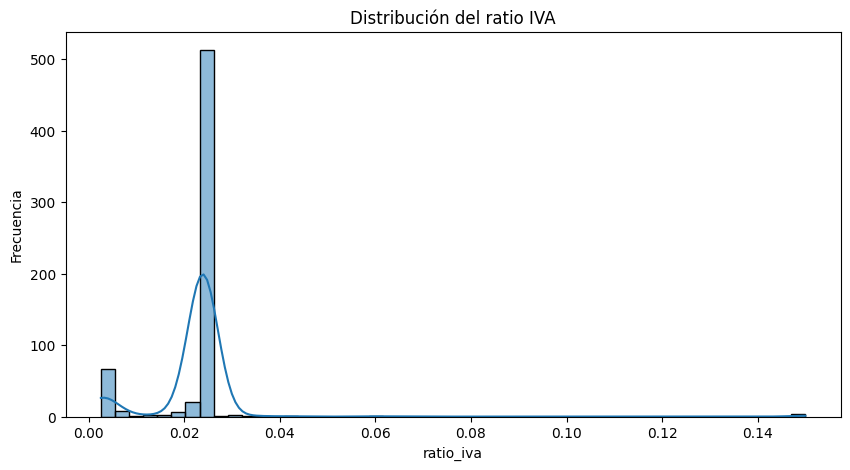

In [1009]:
plt.figure(figsize=(10,5))
sns.histplot(data = df_iva, x = "ratio_iva", bins=50, kde=True)

plt.title("Distribución del ratio IVA")
plt.xlabel("ratio_iva")
plt.ylabel("Frecuencia")
plt.show()

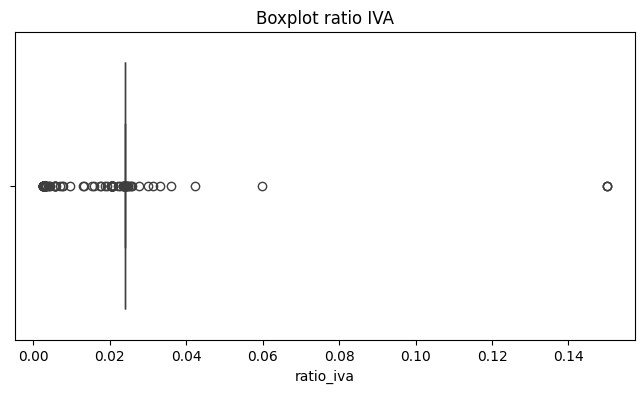

In [1010]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_iva["ratio_iva"])

plt.title("Boxplot ratio IVA")
plt.show()

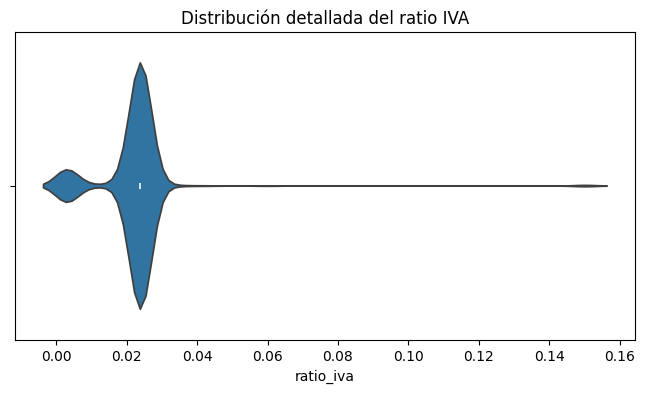

In [1011]:
plt.figure(figsize=(8,4))
sns.violinplot(x=df_iva["ratio_iva"])

plt.title("Distribución detallada del ratio IVA")
plt.show()

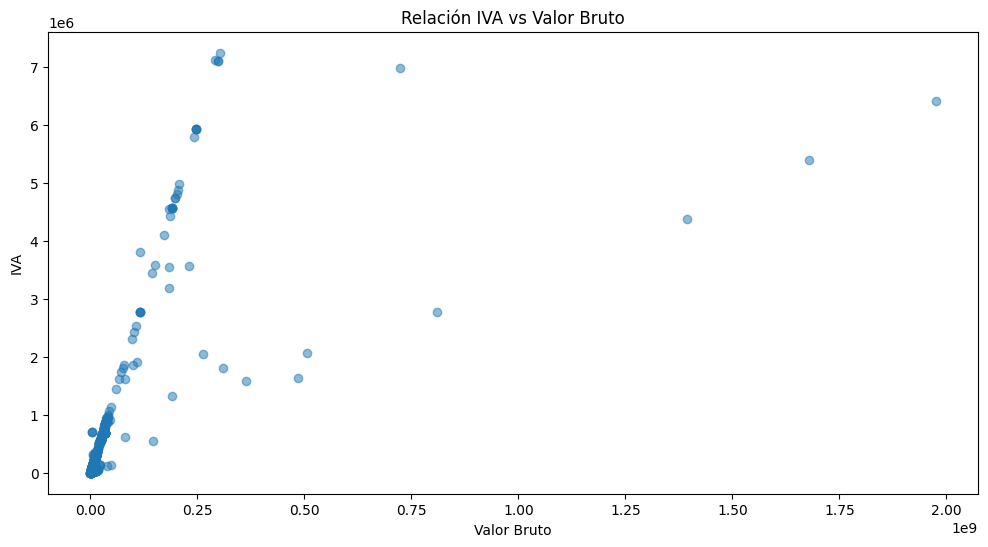

In [1012]:
plt.figure(figsize=(12,6))
plt.scatter(df_iva["Valor Bruto"], df_iva["IVA"], alpha=0.5)

plt.xlabel("Valor Bruto")
plt.ylabel("IVA")
plt.title("Relación IVA vs Valor Bruto")
plt.show()

#### 🚨 Hallazgo

A partir del análisis del campo ratio_iva (IVA / Valor Bruto), se identificaron registros con valores atípicos frente a las tarifas estándar del impuesto en Colombia.

En particular:

- Existe una concentración dominante de registros alrededor de un valor cercano a 2.3–2.5%, siendo estos no consistentes con las tarifas comunes de IVA.

Se detectaron:
- 625 Giros con valores significativamente inferiores al rango esperado (5% ó 19%).
- 3 Giros con IVA del 15%

Estos comportamientos indican posibles inconsistencias en la liquidación, registro o clasificación del impuesto.

De acuerdo con la normativa tributaria colombiana (estatuto tributario y reglamentación vigente):

El IVA debe aplicarse conforme a tarifas definidas (ej. 0%, 5%, 19%)
La relación entre IVA y base gravable debe ser consistente y proporcional
Los registros contables deben reflejar correctamente la naturaleza:
- Gravado
- Exento
- Excluido

Se incluirán estos giros tesorales en la muestra

#### ✅ Agregar indices al diccionario de giros

In [1013]:
for idx in df_iva["id_unico"]:
    giros.update({idx:"Riesgo por IVA Incorrecto"})

### Análisis de descuentos

#### Inconsistencias relativas de los descuentos

Se presenta cuando un giro no sigue el patrón esperado de su grupo.

- Para ello se evalúa la proporción del valor bruto que va al tota de descuentos.
- Se calcula el Z-Score en base al tipo de gasto. Esto permite comparar los descuentos sin importar la escala.
- Y se filtra tomando 2 desviaciones estándar como casos atípicos. Para disminuir la cantidad de muestra, debido a que tomando 2 desviaciones estándar obtenemos 911 giros tesorales

In [1014]:
df["pct_descuento"] = np.where(
    df["Valor Bruto"] > 0,
    df["Total descuentos"] / df["Valor Bruto"],
    np.nan
)

In [1015]:
df["zscore_grupo_desc"] = (
    df.groupby("Tipo de gasto")["pct_descuento"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

df_inconsistentes = df[abs(df["zscore_grupo_desc"]) > 4]
df_inconsistentes

C:\Users\DVadeus\AppData\Local\Temp\ipykernel_13292\212337630.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Tipo de gasto")["pct_descuento"]


,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Total descuentos,Valor Neto,Cuenta contable,Credito,id_unico,año,mes,ratio_iva,pct_descuento,zscore_grupo_desc
301,2021,196,1111769753,2021-04-15,2.403102e+10,BANCO CAJA SOCIAL S.A.,DARLYNG VEGA PANAMEÑO,NATURAL,SERVICIOS,2021-03-05,...,1024141.0,7910686,1110,7910686,196_1111769753_,2021,4,NaN,0.114623,4.040847
344,2021,315,52469447,2021-04-23,2.219497e+10,BANCOLOMBIA S A,MARIA ANDREA ROZO MEDINA,NATURAL,SERVICIOS,2021-02-11,...,1387930.0,10507550,1110,10507550,315_52469447_,2021,4,NaN,0.116677,4.145453
366,2021,403,40030562,2021-05-07,2.409362e+10,BANCO CAJA SOCIAL S.A.,MARTHA LUCIA HUERTAS MOLANO,NATURAL,SERVICIOS,2021-03-09,...,1347018.0,9755430,1110,9755430,403_40030562_,2021,5,NaN,0.121326,4.382268
378,2021,442,56077841,2021-05-10,5.500099e+14,BANCO DAVIVIENDA S.A.,AILEN PATRICIA ESPINOZA LUNA,NATURAL,SERVICIOS,2021-03-17,...,1237861.0,9071555,1110,9071555,442_56077841_,2021,5,NaN,0.120071,4.318326
416,2021,521,79108593,2021-05-13,5.500099e+14,BANCO DAVIVIENDA S.A.,MIGUEL ALFONSO GORDO GRANADOS,NATURAL,SERVICIOS,2021-03-16,...,1547652.0,11140860,1110,11140860,521_79108593_,2021,5,NaN,0.121973,4.415199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13025,2023,5059,79548029,2023-09-04,5.965964e+10,BANCOLOMBIA S A,JORGE ELIECER GAITAN TORRES,NATURAL,SERVICIOS,2023-04-04,...,6875808.0,47046192,1110,47046192,5059_79548029_,2023,9,NaN,0.127514,4.697458
14098,2023,7661,45495531,2023-11-09,5.965964e+10,BANCOLOMBIA S A,JORGE ELIECER GAITAN TORRES,NATURAL,SERVICIOS,2023-04-04,...,19594991.0,111619009,1110,111619009,7661_45495531_,2023,11,NaN,0.149336,5.809028
14854,2023,9187,43612348,2023-12-21,4.289009e+10,BANCOLOMBIA S A,JACK JONATHAN MEDINA ROJAS,NATURAL,SERVICIOS,2023-08-28,...,537488.0,3492512,1110,3492512,9187_43612348_,2023,12,NaN,0.133372,4.995838
14965,2023,9516,79548029,2023-12-27,5.965964e+10,BANCOLOMBIA S A,JORGE ELIECER GAITAN TORRES,NATURAL,SERVICIOS,2023-04-04,...,5671936.0,32309064,1110,32309064,9516_79548029_,2023,12,NaN,0.149336,5.809029


#### ✅ Agregar indices al diccionario de giros

In [1016]:
for idx in df_inconsistentes["id_unico"]:
    giros.update({idx:"Inconsistencia relativa de descuento > 4 Z-Score"})

Ahora se procede a revisar la composición de los descuentos.

Comparando el ``Total descuentos`` con el ``cálculo de los descuentos``

In [1017]:
componentes = [
    "IVA", "ICA", "ReteFte", "ReteICA", "ReteIVA",
    "Estampilla", "Estampilla Universidad FJC",
    "Adulto mayor", "Otros descuentos"
]

df["suma_componentes"] = df[componentes].sum(axis=1)

df["diff_componentes"] = df["Total descuentos"] - df["suma_componentes"]

# Casos inconsistentes
df_componentes = df[np.abs(df["diff_componentes"]) > 1].sort_values(by = "diff_componentes", ascending = False).head(20)
df_componentes

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Cuenta contable,Credito,id_unico,año,mes,ratio_iva,pct_descuento,zscore_grupo_desc,suma_componentes,diff_componentes
14126,2023,7766,45495531,2023-11-10,1.841500e+05,BANCO DE BOGOTA,ESRI COLOMBIA S.A.S,JURIDICA,SERVICIOS,2023-04-17,...,1110,1098378966,7766_45495531_,2023,11,NaN,0.042900,0.387420,15837038.0,33395496.0
13058,2023,5112,901373456,2023-09-04,7.947202e+07,CITIBANK - COLOMBIA S A,UNION TEMPORAL SOFT IG.3,JURIDICA,SERVICIOS,2023-08-28,...,1110,610983628,5112_901373456_,2023,9,NaN,0.042900,0.387420,8809502.0,18576558.0
12846,2023,4680,900105979,2023-08-24,5.288278e+08,BANCOLOMBIA S A,BUSINESSMIND COLOMBIA S.A.,JURIDICA,SERVICIOS,2023-08-24,...,1110,608603068,4680_900105979_,2023,8,NaN,0.080660,2.310826,35959840.0,17437080.0
14127,2023,7771,45495531,2023-11-14,5.288278e+08,BANCOLOMBIA S A,BUSINESSMIND COLOMBIA S.A.,JURIDICA,SERVICIOS,2023-08-18,...,1110,302849374,7771_45495531_,2023,11,NaN,0.080660,2.310826,17894117.0,8676935.0
15015,2023,9600,860045379,2023-12-28,5.400933e+07,ITAÚ CORPBANCA COLOMBIA S A,COMWARE S. A.,JURIDICA,SERVICIOS,2023-10-13,...,1110,229041600,9600_860045379_,2023,12,NaN,0.045660,0.528008,4636800.0,6321600.0
15014,2023,9599,860045379,2023-12-28,5.400933e+07,ITAÚ CORPBANCA COLOMBIA S A,COMWARE S. A.,JURIDICA,SERVICIOS,2023-10-13,...,1110,217108246,9599_860045379_,2023,12,NaN,0.045660,0.528008,4395216.0,5992238.0
14098,2023,7661,45495531,2023-11-09,5.965964e+10,BANCOLOMBIA S A,JORGE ELIECER GAITAN TORRES,NATURAL,SERVICIOS,2023-04-04,...,1110,111619009,7661_45495531_,2023,11,NaN,0.149336,5.809028,15979439.0,3615552.0
14957,2023,9488,901719381,2023-12-26,2.412310e+10,BANCO CAJA SOCIAL S.A.,UNION TEMPORAL OMEGA 2023,JURIDICA,SERVICIOS,2023-06-07,...,1110,92864703,9488_901719381_,2023,12,NaN,0.095933,3.088786,7580475.0,2273625.0
14154,2023,7806,45495531,2023-11-15,2.412310e+10,BANCO CAJA SOCIAL S.A.,UNION TEMPORAL OMEGA 2023,JURIDICA,SERVICIOS,2023-06-07,...,1110,88186101,7806_45495531_,2023,11,NaN,0.095933,3.088786,7198565.0,2159078.0
13025,2023,5059,79548029,2023-09-04,5.965964e+10,BANCOLOMBIA S A,JORGE ELIECER GAITAN TORRES,NATURAL,SERVICIOS,2023-04-04,...,1110,47046192,5059_79548029_,2023,9,NaN,0.127514,4.697458,5390007.0,1485801.0


Se encuentran 12.935 giros con diferencias entre ``Total descuentos`` y la suma de estos de manera manual, se ordenan de mayor a menor y se extraen los primeros 20 para la muestra.

#### ✅ Agregar indices al diccionario de giros

In [1018]:
for idx in df_componentes["id_unico"]:
    giros.update({idx:"Diferencia considerable entre Total descuentos y Descuentos Calculados"})

Se revisa además los giros con valor bruto superior a $10.000.000 de pesos a los cuales no se les haya aplicado algún descuento.

In [1019]:
giros_sin_descuento = df[(df["Total descuentos"] == 0) & (df["Valor Bruto"] > 10_000_000)].sort_values("Valor Bruto", ascending=False).head(20)   # pagos grandes sin descuento
giros_sin_descuento

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Cuenta contable,Credito,id_unico,año,mes,ratio_iva,pct_descuento,zscore_grupo_desc,suma_componentes,diff_componentes
5069,2022,2482,901023218,2022-06-16,8.330259e+08,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S A,HQ5 SAS,JURIDICA,CONTRATO,2022-02-26,...,1110,1439307910,2482_901023218_,2022,6,NaN,0.0,-3.520117,0.0,0.0
3896,2022,8226,900062917,2022-10-28,2.218063e+08,BANCO DE OCCIDENTE,SERVICIOS POSTALES NACIONALES S A,JURIDICA,SERVICIOS,2022-07-08,...,1110,813074946,8226_900062917_,2022,10,NaN,0.0,-1.797806,0.0,0.0
3179,2021,6776,899999230,2021-12-28,2.308589e+08,BANCO DE OCCIDENTE,UNIVERSIDAD DISTRITAL FRANCISCO JOSE DE CALDAS,JURIDICA,SERVICIOS,2021-07-14,...,1110,61880000,6776_899999230_,2021,12,NaN,0.0,-1.797806,0.0,0.0
10956,2023,12774,899999230,2023-11-10,2.308589e+08,BANCO DE OCCIDENTE,UNIVERSIDAD DISTRITAL FRANCISCO JOSE DE CALDAS,JURIDICA,SERVICIOS,2023-03-22,...,1110,43680000,12774_899999230_,2023,11,NaN,0.0,-1.797806,0.0,0.0
10833,2023,12403,899999115,2023-04-03,2.093603e+07,CITIBANK - COLOMBIA S A,EMPRESA DE TELECOMUNICACIONES DE BOGOTA SA ES...,JURIDICA,SERVICIOS,2023-12-29,...,1110,42927838,12403_899999115_,2023,4,NaN,0.0,-1.797806,0.0,0.0
10869,2023,12455,899999115,2023-04-10,2.093603e+07,CITIBANK - COLOMBIA S A,EMPRESA DE TELECOMUNICACIONES DE BOGOTA SA ES...,JURIDICA,SERVICIOS,2023-12-29,...,1110,42925521,12455_899999115_,2023,4,NaN,0.0,-1.797806,0.0,0.0
10870,2023,12456,899999115,2023-04-10,2.093603e+07,CITIBANK - COLOMBIA S A,EMPRESA DE TELECOMUNICACIONES DE BOGOTA SA ES...,JURIDICA,SERVICIOS,2023-12-29,...,1110,42874740,12456_899999115_,2023,4,NaN,0.0,-1.797806,0.0,0.0
10934,2023,12718,899999115,2023-09-04,2.093603e+07,CITIBANK - COLOMBIA S A,EMPRESA DE TELECOMUNICACIONES DE BOGOTA SA ES...,JURIDICA,SERVICIOS,2023-12-29,...,1110,37856368,12718_899999115_,2023,9,NaN,0.0,-1.797806,0.0,0.0
3902,2022,8253,899999230,2022-12-02,2.308589e+08,BANCO DE OCCIDENTE,UNIVERSIDAD DISTRITAL FRANCISCO JOSE DE CALDAS,JURIDICA,SERVICIOS,2022-04-13,...,1110,25491000,8253_899999230_,2022,12,NaN,0.0,-1.797806,0.0,0.0
14378,2023,8268,45495531,2023-12-04,3.590129e+08,BANCO DE BOGOTA,INVERSIONES LEE CARDENAS S.A.S,JURIDICA,SERVICIOS,2023-12-01,...,1110,20930955,8268_45495531_,2023,12,NaN,0.0,-1.797806,0.0,0.0


#### ✅ Agregar indices al diccionario de giros

In [1020]:
for idx in giros_sin_descuento["id_unico"]:
    giros.update({idx:"Giros de monto alto sin descuento"})

## Fase 3 - Análisis por Tercero

### Verificación de integridad de datos entre ``ID_Tercero`` y ``Razón Social``

In [1021]:
df_cuentas = (
    df.groupby("ID_Tercero")["Razon_Social"]
    .nunique()
    .reset_index(name="Razón Social")
)

# Filtrar sospechosos
benef_multi_razon = df_cuentas[df_cuentas["Razón Social"] > 1]

benef_multi_razon.sort_values(by="Razón Social", ascending=False).head(20)

,ID_Tercero,Razón Social
307,45495531,392
297,43612348,286
363,52349259,4


In [1022]:
multi_razon = df[df["ID_Tercero"].isin(benef_multi_razon["ID_Tercero"])]
multi_razon

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Cuenta contable,Credito,id_unico,año,mes,ratio_iva,pct_descuento,zscore_grupo_desc,suma_componentes,diff_componentes
5940,2022,4287,45495531,2022-08-16,140712258.0,BANCO DAVIVIENDA S.A.,MARTA PATRICIA PUELLO VEGA,NATURAL,SERVICIOS,2022-07-19,...,1110,1706114,4287_45495531_,2022,8,NaN,0.033000,-0.116839,72339.0,-14115.0
6851,2022,5591,45495531,2022-09-14,140712258.0,BANCO DAVIVIENDA S.A.,MARTA PATRICIA PUELLO VEGA,NATURAL,SERVICIOS,2022-07-19,...,1110,4267566,5591_45495531_,2022,9,NaN,0.032483,-0.143192,176285.0,-33007.0
7849,2022,7081,45495531,2022-10-20,140712258.0,BANCO DAVIVIENDA S.A.,MARTA PATRICIA PUELLO VEGA,NATURAL,SERVICIOS,2022-07-19,...,1110,4269309,7081_45495531_,2022,10,NaN,0.032088,-0.163320,172799.0,-31264.0
8913,2022,8679,45495531,2022-11-18,140712258.0,BANCO DAVIVIENDA S.A.,MARTA PATRICIA PUELLO VEGA,NATURAL,SERVICIOS,2022-07-19,...,1110,4269309,8679_45495531_,2022,11,NaN,0.032088,-0.163320,172799.0,-31264.0
10077,2022,10624,45495531,2022-12-22,140712258.0,BANCO DAVIVIENDA S.A.,MARTA PATRICIA PUELLO VEGA,NATURAL,SERVICIOS,2022-07-19,...,1110,4269309,10624_45495531_,2022,12,NaN,0.032088,-0.163320,172799.0,-31264.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16392,2024,1867,45495531,2024-07-16,140712258.0,BANCO DAVIVIENDA S.A.,MARTA PATRICIA PUELLO VEGA,NATURAL,SERVICIOS,2024-02-05,...,1110,4503291,1867_45495531_,2024,7,NaN,0.027658,-0.388971,140405.0,-12310.0
16508,2024,2320,45495531,2024-08-16,140712258.0,BANCO DAVIVIENDA S.A.,MARTA PATRICIA PUELLO VEGA,NATURAL,SERVICIOS,2024-02-05,...,1110,4503291,2320_45495531_,2024,8,NaN,0.027658,-0.388971,140405.0,-12310.0
16602,2024,2732,45495531,2024-09-18,140712258.0,BANCO DAVIVIENDA S.A.,MARTA PATRICIA PUELLO VEGA,NATURAL,SERVICIOS,2024-02-05,...,1110,4503291,2732_45495531_,2024,9,NaN,0.027658,-0.388971,140405.0,-12310.0
16702,2024,3186,45495531,2024-10-18,140712258.0,BANCO DAVIVIENDA S.A.,MARTA PATRICIA PUELLO VEGA,NATURAL,SERVICIOS,2024-02-05,...,1110,4503291,3186_45495531_,2024,10,NaN,0.027658,-0.388971,140405.0,-12310.0


#### 🚨 Hallazgo

Los ``ID_Tercero`` 45495531, 43612348 y 43612348

Están asociados a:

- Cientos de personas naturales distintas
- Empresas completamente diferentes
- Entidades públicas y privadas
- Uniones temporales
- Operadores de telecomunicaciones y servicios públicos

Afectando a 1194 giros tesorales

Esto supone un problema de integridad crítico, debido a que no es posible confiar en un:

- Un análisis por beneficiario
- Una consolidación de pagos
- Una trazabilidad de giros

Además de esto, existen riesgos en áreas como:

- Dinero asignado a quien no corresponde.
- Imposibilidad de  reconstruir quién recibió qué.
- El uso de identificadores genéricos para dispersar pagos.

El identificador de terceros ``ID_Tercero`` debe ser **único** y representar de manera inequívoca a un beneficiario dentro del sistema.

Por lo tanto, el ``ID_Tercero`` no representa una entidad válida, sino un contenedor de múltiples beneficiarios, lo que evidencia una **falla crítica en la calidad y gestión de los datos**.

Se evalúa a continuación el impacto de los IDs genéricos en el set de datos:

In [1023]:
# Sumatoria de valor neto de los IDs genéricos

total = multi_razon["Valor Neto"].sum()
formatted = f"${total:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")
print(formatted)

$7.070.076.797


In [1024]:
multi_razon.groupby("Razon_Social")["Valor Neto"].sum().sort_values(ascending=False)

Razon_Social
ESRI COLOMBIA S.A.S                                                        1098378966
BUSINESSMIND COLOMBIA S.A.                                                  302849374
CHALJUB RESTREPO & CIA S.C.A.                                               244984080
UNION TEMPORAL G7                                                           127592500
JORGE ELIECER GAITAN TORRES                                                 111619009
                                                                              ...    
AQUAOCCIDENTE S.A. E.S.P                                                       262040
EMPRESAS PUBLICAS DE ARMENIA E S P                                             177507
ALEJANDRA  TELLEZ CELY                                                         143352
COMUNICACION CELULAR S A COMCEL S A                                            136402
E.S.P. EMPRESA DE OBRAS SANITARIAS DE SANTA ROSA DE CABAL - E.I.C.E.            90603
Name: Valor Neto, Length: 417, dtype: int

En total se encuentran 417 Razones Sociales asociadas a IDs genéricos.

In [1025]:
impacto_ids = (
    df[df["ID_Tercero"].isin(multi_razon["ID_Tercero"])]
    .groupby("ID_Tercero")
    .agg(
        valor_total=("Valor Neto", "sum"),
        num_giros=("id_unico", "count"),
        num_nombres=("Razon_Social", "nunique")
    )
    .reset_index()
)

impacto_ids = impacto_ids.sort_values(by="valor_total", ascending=False)
impacto_ids

,ID_Tercero,valor_total,num_giros,num_nombres
1,45495531,5170631856,814,392
0,43612348,1848952372,372,286
2,52349259,50492569,8,4


#### ⚠️ Por revisar

Para este informe no es posible usar ``ID_Tercero`` como característica de análisis, debido a que no representa una identidad única para cada ``Razón Social``. Se procede a incluir estos giros tesorales a la muestra.

#### ✅ Agregar índices al diccionario de giros

In [1026]:
for idx in multi_razon["id_unico"]:
    giros.update({idx:"Riesgo Crítico: ID Genérico"})

### Beneficiarios con múltiples cuentas bancarias

Se procede a revisar si existen beneficiarios con diferentes cuentas bancarias.

Sin embargo, debido a que no es posible utilizar los 3 ``ID_Tercero`` genéricos, se procede a eliminar los ID genéricos de este análisis y se agruparán con ``Razon_Social``.

In [1027]:
df_cuentas = df[~df["ID_Tercero"].isin(benef_multi_razon["ID_Tercero"])]

In [1028]:
df_cuentas = (
    df.groupby(["ID_Tercero", "Razon_Social"])["Número de cuenta"]
    .nunique()
    .reset_index(name="Número de cuenta")
)

# Filtrar sospechosos
benef_multi_cuentas = df_cuentas[df_cuentas["Número de cuenta"] > 1]

benef_multi_cuentas.sort_values(by="Número de cuenta", ascending=False)

,ID_Tercero,Razon_Social,Número de cuenta
16,6805955,CESAR AUGUSTO VARGAS BARRERA,4
1701,1047382496,MARTIN ALFREDO LAMBIS JARAVA,4
1628,1023903001,YULY ELIANA MENDIVELSO CARO,3
205,28627633,MAGDA CRISTINA MONTAÑA MURILLO,3
1143,73208296,JORGE DAVID NADAFF TORRES,3
...,...,...,...
2085,1143352891,ANNEN ROCHA PUERTAS,2
2100,1143871258,ALEXANDER PRETEL DIAZ,2
2095,1143385516,BRENDA JULIETH MARTINEZ HENAO,2
2110,1144148506,YIMMY ALEXANDER BURGOS ORTEGA,2


#### ⚠️ Por revisar

Se han detectado **184** Beneficiarios con más de 2 cuentas bancarias llegando a un máximo de 4 cuentas bancarias. Sin embargo este resultado es sesgado, debido a qué eliminaron del análisis **1194** giros debido a la duplicidad del ``ID_Tercero``

Se procede a agregar los terceros con más de 2 cuentas bancarias a la muestra.

#### ✅ Agregar índices al diccionario de giros

In [1029]:
benef_multi_cuentas = df_cuentas[df_cuentas["Número de cuenta"] > 2]

df_tercero = df[df["ID_Tercero"].isin(benef_multi_cuentas["ID_Tercero"])]

for idx in df_tercero["id_unico"]:
    giros.update({idx:"Tercero con 3 o más cuentas bancarias"})

### Beneficiarios con múltiples ``ID_Tercero``

In [1030]:
df_ids = (
    df_cuentas.groupby("Razon_Social")["ID_Tercero"]
    .nunique()
    .reset_index(name="num_ids")
)

benef_multi_ids = df_ids[df_ids["num_ids"] > 1]

benef_multi_ids.sort_values(by="num_ids", ascending=False).head(20)

,Razon_Social,num_ids
47,ALVARO JOSE MELO VILLAMIZAR,3
1457,YURY ALEJANDRA CARVAJAL REINA,3
4,ADRIANA ROCIO CACAIS GALINDO,3
1425,YEISON ALEJANDRO SANCHEZ GONZALEZ,3
1426,YEISON ALEXANDER JIMENEZ NUÑEZ,3
1437,YIMMY ALEXANDER BURGOS ORTEGA,3
1440,YIRNY JULIETH RENTERIA MATURANA,3
1272,RUBEN DARIO RIOS ARANGO,3
1274,RUBIEL ALBEIRO MURCIA GÓMEZ,3
1278,SALMA ELENA CALDAS OTERO,3


In [1031]:
tercero = df_cuentas[df_cuentas["Razon_Social"].isin(benef_multi_ids["Razon_Social"])] \
    .sort_values(["Razon_Social", "ID_Tercero"])

tercero

,ID_Tercero,Razon_Social,Número de cuenta
297,43612348,ADRIANA ROCIO CACAIS GALINDO,1
592,45495531,ADRIANA ROCIO CACAIS GALINDO,1
1606,1022363323,ADRIANA ROCIO CACAIS GALINDO,2
298,43612348,AGUAS DE CARTAGENA SA,0
593,45495531,AGUAS DE CARTAGENA SA,0
...,...,...,...
982,45495531,YULITZA DIAZ GONZALEZ,1
1950,1094963758,YULITZA DIAZ GONZALEZ,1
582,43612348,YURY ALEJANDRA CARVAJAL REINA,1
983,45495531,YURY ALEJANDRA CARVAJAL REINA,1


Se agrega esta tabla a un archivo excel para su uso en la solicitud de aclaraciones de auditoría.

In [1032]:
tercero.to_excel("tercero_multiples_id_y_cuentas.xlsx", index = False)

#### ⚠️ Por revisar

Se identificaron beneficiarios asociados a múltiples cuentas bancarias y además múltiples identificadores (``ID_Tercero``) asociados una misma razón social.

En base al segundo punto, es probable que esto se deba a que pueden haber 2 o más personas con el mismo nombre, sin embargo se aclara que también se encuentran en la lista empresas con 2 o más ``ID_Tercero``. Incluso empresas con ``ID_Tercero`` de cédula en vez de NIT.

Esto puede romper el principio de unicidad en el registro de terceros.

Pudiendo llegar a ser un riesgo en los siguientes casos:

- Pagos dirigidos a cuentas no autorizadas.
- Duplicidad de beneficiarios.
- Debilidad en controles de integridad de datos.

Se recomienda solicitar las certificaciones bancarias de los ``ID_Tercero`` con múltiples cuentas bancarias  para esta manera descartar posibles suplantaciones y además verificar que cada Razón social sea única con su respectivo identificador.

### Giros sin cuenta bancaria registrada

In [1033]:
sin_cuenta = df[df["Número de cuenta"].isna()]
sin_cuenta

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Cuenta contable,Credito,id_unico,año,mes,ratio_iva,pct_descuento,zscore_grupo_desc,suma_componentes,diff_componentes
654,2021,1511,816002019,2021-07-12,NaN,NaN,EMPRESA DE ENERGIA DE PEREIRA S.A E.S.P,JURIDICA,SERVICIOS,2021-07-12,...,1110,193096,1511_816002019_,2021,7,NaN,0.000000,-1.797806,0.0,0.0
734,2021,1674,901399373,2021-07-14,NaN,NaN,UNION TEMPORAL DELL EMC,JURIDICA,SERVICIOS,2021-05-28,...,1110,148692,1674_901399373_,2021,7,NaN,0.071035,1.820550,13137.0,-1767.0
744,2021,1688,900651752,2021-07-19,NaN,NaN,AQUAOCCIDENTE S.A. E.S.P,JURIDICA,SERVICIOS,2021-07-19,...,1110,63660,1688_900651752_,2021,7,NaN,0.000000,-1.797806,0.0,0.0
771,2021,1727,800249860,2021-08-02,NaN,NaN,CELSIA COLOMBIA S.A E.S.P,JURIDICA,SERVICIOS,2021-07-29,...,1110,263314,1727_800249860_,2021,8,NaN,0.000000,-1.797806,0.0,0.0
828,2021,2006,816002019,2021-08-09,NaN,NaN,EMPRESA DE ENERGIA DE PEREIRA S.A E.S.P,JURIDICA,SERVICIOS,2021-08-09,...,1110,840875,2006_816002019_,2021,8,NaN,0.000000,-1.797806,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16349,2024,1734,901394489,2024-07-09,NaN,NaN,SERVIRED LMA COMUNICACIONES S.A.S.,JURIDICA,SERVICIOS,2024-05-30,...,1110,280279,1734_901394489_,2024,7,NaN,0.000000,-1.797806,0.0,0.0
16365,2024,1800,830114921,2024-07-11,NaN,NaN,COLOMBIA MOVIL S A E S P,JURIDICA,SERVICIOS,2024-05-30,...,1110,649988,1800_830114921_,2024,7,NaN,0.000000,-1.797806,0.0,0.0
16460,2024,2122,830114921,2024-08-09,NaN,NaN,COLOMBIA MOVIL S A E S P,JURIDICA,SERVICIOS,2024-05-30,...,1110,649988,2122_830114921_,2024,8,NaN,0.000000,-1.797806,0.0,0.0
16560,2024,2559,830114921,2024-09-06,NaN,NaN,COLOMBIA MOVIL S A E S P,JURIDICA,SERVICIOS,2024-05-30,...,1110,649988,2559_830114921_,2024,9,NaN,0.000000,-1.797806,0.0,0.0


#### ⚠️ Por revisar

Un giro sin cuenta bancaria no permite realizar trazabilidad del destino del dinero

Por lo que no es posible verificar si:

- El proveedor es real.
- Cuál es el banco al cuál fue envíado el dinero.
- Verificar si el número de cuenta es del tercero.

Por lo anterior, este caso puede llegar a ser de un riesgo alto ya que da la posibilidad de:

- Sean pagos indebidos.
- Sean registros manipulados.
- Existan fallas en los controles internos de catastro.

Es por ello, que es necesario validar con catastro si el giro fue efectuado por:

- Caja menor
- Pago en efectivo
- Ajustes contables

Sin embargo, según el set de datos. Todos los tipos de giros son **``Transferencia``**

Se procede a agregar estos giros a la muestra.

#### ✅ Agregar índices al diccionario de giros

In [1034]:
for idx in sin_cuenta["id_unico"]:
    giros.update({idx:"No hay cuenta bancaria asociada"})

### Frecuencia de pagos

Para este análisis serán descartados los ``ID_Tercero`` genéricos. Debido a que ocasionarán ruido sistemático a la detección de pagos fraccionados.

In [1035]:
df_cuentas = df[~df["ID_Tercero"].isin(benef_multi_razon["ID_Tercero"])]

In [1036]:
df_cuentas

,Vigencia,Número de orden de pago,ID_Tercero,Fecha Giro,Número de cuenta,Banco,Razon_Social,Tipo de persona,Tipo de gasto,Fecha CRP,...,Cuenta contable,Credito,id_unico,año,mes,ratio_iva,pct_descuento,zscore_grupo_desc,suma_componentes,diff_componentes
0,2021,2991,1088259568,2021-02-03,1.272702e+11,BANCO DAVIVIENDA S.A.,YONNY ANDRES CRUZ BENJUMEA,NATURAL,SERVICIOS,2021-04-26,...,1110,1499478,2991_1088259568_,2021,2,NaN,0.040334,0.256718,79169.0,-16147.0
1,2021,2992,1088259568,2021-02-03,1.272702e+11,BANCO DAVIVIENDA S.A.,YONNY ANDRES CRUZ BENJUMEA,NATURAL,SERVICIOS,2021-06-21,...,1110,312500,2992_1088259568_,2021,2,NaN,0.000000,-1.797806,0.0,0.0
2,2021,3001,52539367,2021-02-04,5.700089e+14,BANCO DAVIVIENDA S.A.,ALEXANDRA VARGAS PINILLA,NATURAL,SERVICIOS,2021-05-12,...,1110,7290786,3001_52539367_,2021,2,NaN,0.069697,1.752387,619503.0,-73289.0
3,2021,3047,1094938732,2021-02-08,1.202372e+08,BANCOLOMBIA S A,MARIA ALEJANDRA LONDOÑO JIMENEZ,NATURAL,SERVICIOS,2021-06-21,...,1110,1447500,3047_1094938732_,2021,2,NaN,0.035000,-0.014988,67500.0,-15000.0
4,2021,3053,1093773164,2021-02-08,5.704574e+14,BANCO DAVIVIENDA S.A.,JURGEN DANIEL TOLOZA DELGADO,NATURAL,SERVICIOS,2021-06-03,...,1110,6184861,3053_1093773164_,2021,2,0.02395,0.052268,0.864605,545098.0,-203999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16895,2024,4624,1113512793,2024-12-28,8.582164e+10,BANCOLOMBIA S A,MARY YULIANA JARAMILLO,NATURAL,SERVICIOS,2024-02-01,...,1110,6757313,4624_1113512793_,2024,12,NaN,0.027316,-0.406396,205855.0,-16089.0
16896,2024,4640,1143338180,2024-12-29,7.880001e+10,BANCOLOMBIA S A,YELIZA MERCEDES PEREZ LICONA,NATURAL,SERVICIOS,2024-02-01,...,1110,2628219,4640_1143338180_,2024,12,NaN,0.027177,-0.413464,79305.0,-5882.0
16897,2024,4641,1047368991,2024-12-29,5.660018e+10,BANCO DAVIVIENDA S.A.,LUISA FERNANDA LARIOS DIAZ,NATURAL,SERVICIOS,2024-01-29,...,1110,2627108,4641_1047368991_,2024,12,NaN,0.027588,-0.392517,81527.0,-6993.0
16898,2024,4653,64564800,2024-12-30,5.770013e+10,BANCO DAVIVIENDA S.A.,SALMA ELENA CALDAS OTERO,NATURAL,SERVICIOS,2024-02-01,...,1110,2,4653_64564800_,2024,12,NaN,0.000000,-1.797806,0.0,0.0


In [1037]:
df_cuentas["periodo"] = df_cuentas["Fecha Giro"].dt.to_period("M")

C:\Users\DVadeus\AppData\Local\Temp\ipykernel_13292\1573847879.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cuentas["periodo"] = df_cuentas["Fecha Giro"].dt.to_period("M")


In [1038]:
giros_mes = (
    df_cuentas.groupby(["ID_Tercero", "Razon_Social", "periodo"])
    .agg(
        num_giros=("id_unico", "count"),
        valor_total=("Valor Neto", "sum"),
        valor_promedio=("Valor Neto", "mean"),
        desviacion=("Valor Neto", "std")
    )
    .reset_index()
)

In [1039]:
giros_mes

,ID_Tercero,Razon_Social,periodo,num_giros,valor_total,valor_promedio,desviacion
0,2631771,ANGEL OSPINA BEJARANO,2022-08,1,3270053,3270053.0,NaN
1,2631771,ANGEL OSPINA BEJARANO,2022-09,1,4268370,4268370.0,NaN
2,2631771,ANGEL OSPINA BEJARANO,2023-02,1,4288028,4288028.0,NaN
3,2761483,MANUEL FRANCISCO CARABALLO QUIÑONEZ,2022-08,1,119460,119460.0,NaN
4,2761483,MANUEL FRANCISCO CARABALLO QUIÑONEZ,2022-09,1,1779482,1779482.0,NaN
...,...,...,...,...,...,...,...
11822,1233903877,JEISON DAVID CUERVO NIÑO,2023-06,1,3135653,3135653.0,NaN
11823,1233903877,JEISON DAVID CUERVO NIÑO,2023-07,1,2844524,2844524.0,NaN
11824,1233903877,JEISON DAVID CUERVO NIÑO,2023-09,1,4269354,4269354.0,NaN
11825,1238338769,CINDY PAOLA VARGAS SEÑA,2022-11,1,1066321,1066321.0,NaN


Se procede a evaluar si un mismo tercero recibe pagos **pequeños** en un mismo periodo, en cuyo caso será tomado el mes.

Con la posible intención de evadir controles o evitar topes de aprobación del giro.

- De esta manera se detecta si se realizan varios giros en montos pequeños en vez de uno solo grande.

In [1049]:
giros_mes["coef_variacion"] = giros_mes["desviacion"] / giros_mes["valor_promedio"]

pagos_fraccionados = giros_mes[
    (giros_mes["num_giros"] >= 3) &
    (giros_mes["coef_variacion"] < 0.5)  # montos similares
].sort_values(by="valor_total", ascending=False)

In [1050]:
pagos_fraccionados

,ID_Tercero,Razon_Social,periodo,num_giros,valor_total,valor_promedio,desviacion,coef_variacion
6157,901023218,HQ5 SAS,2022-06,3,4103620345,1.367873e+09,6.293123e+08,4.600662e-01
5747,800076404,AEROESTUDIOS S.A.S,2023-07,3,498693934,1.662313e+08,2.660387e+07,1.600413e-01
5924,830136779,DATUM INGENIERIA LTDA,2022-12,3,294675271,9.822509e+07,5.773503e-01,5.877829e-09
6142,900723117,CHALJUB RESTREPO & CIA S.C.A.,2022-12,7,186993019,2.671329e+07,1.223992e+07,4.581959e-01
6143,900723117,CHALJUB RESTREPO & CIA S.C.A.,2023-04,5,166023703,3.320474e+07,1.074429e+06,3.235769e-02
...,...,...,...,...,...,...,...,...
1262,19393579,JAIRO MURCIA,2022-02,3,53400,1.780000e+04,0.000000e+00,0.000000e+00
4814,80059269,ALVARO HERNAN ORTEGA GUZMAN,2022-11,3,53400,1.780000e+04,0.000000e+00,0.000000e+00
3717,74327879,SEGUNDO FERRER MENDOZA TORRES,2022-11,3,53400,1.780000e+04,0.000000e+00,0.000000e+00
99,5638847,LUIS FERNANDO OLARTE GALVIS,2022-04,3,53400,1.780000e+04,0.000000e+00,0.000000e+00


Se procede a evaluar si los montos son relativamente similares utilizando el coeficiente de variación con respecto al valor promedio y se añade un umbral de comparación por el cuantil 0.75 Q3. 

In [ ]:
threshold = df["Valor Neto"].quantile(0.75)
giros_mes["coef_variacion"] = giros_mes["desviacion"] / giros_mes["valor_promedio"]

pagos_fraccionados = giros_mes[
    (giros_mes["num_giros"] >= 3) &
    (giros_mes["valor_promedio"] < threshold) &
    (giros_mes["coef_variacion"] < 0.5)
]

pagos_fraccionados

,ID_Tercero,Razon_Social,periodo,num_giros,valor_total,valor_promedio,desviacion,coef_variacion
50,4226354,LUIS ALFONSO BARAHONA VARGAS,2022-03,3,53400,1.780000e+04,0.000000e+00,0.000000
76,4376030,WILMER GARZON CLAVIJO,2024-04,3,4838145,1.612715e+06,1.075145e+05,0.066667
80,4516911,ANDRES SAENZ TABORDA,2021-09,3,11190981,3.730327e+06,1.327506e+06,0.355869
98,5638847,LUIS FERNANDO OLARTE GALVIS,2022-03,7,124600,1.780000e+04,0.000000e+00,0.000000
99,5638847,LUIS FERNANDO OLARTE GALVIS,2022-04,3,53400,1.780000e+04,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...
11550,1144029365,DIEGO FERNANDO RODRIGUEZ RAYO,2022-12,3,12543335,4.181112e+06,1.448380e+06,0.346410
11647,1144161103,LUISA MARIA TAGUADO SANDOVAL,2023-07,3,8804130,2.934710e+06,4.527737e+05,0.154282
11777,1193120045,DANIELA GALVEZ VALLEJO,2022-12,3,5184579,1.728193e+06,6.810634e+05,0.394090
11813,1233497236,MAURICIO ALEJANDRO CERON GUALTEROS,2022-12,3,6409065,2.136355e+06,7.129693e+05,0.333732


In [ ]:
pagos_fraccionados.to_excel("pagos_fraccionados.xlsx")

### Detección de pagos repetitivos

In [ ]:
pagos_recurrentes = (
    giros_mes.groupby(["ID_Tercero", "Razon_Social"])
    .agg(
        meses_activos=("periodo", "nunique"),
        total_giros=("num_giros", "sum"),
        promedio_giros_mes=("num_giros", "mean"),
        std_giros_mes=("num_giros", "std"),
        promedio_valor=("valor_promedio", "mean"),
        std_valor=("valor_promedio", "std")
    )
    .reset_index()
)

In [ ]:
pagos_repetitivos = pagos_recurrentes[
    (pagos_recurrentes["meses_activos"] >= 3) &
    (pagos_recurrentes["std_valor"] < pagos_recurrentes["promedio_valor"] * 0.3) &
    (pagos_recurrentes["std_giros_mes"] < 1)
].sort_values(by="promedio_valor", ascending=False)

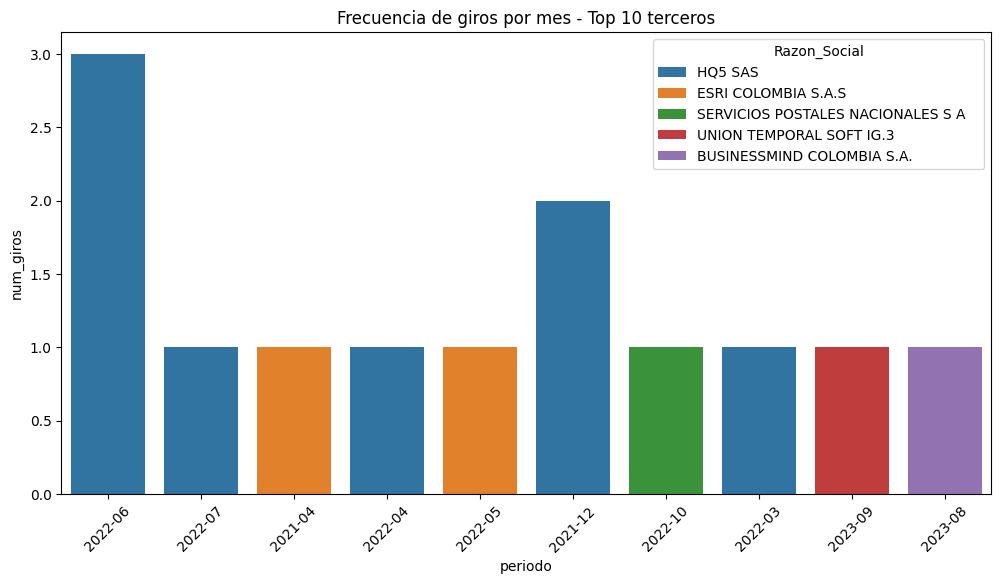

In [ ]:
top = giros_mes.sort_values(by="valor_total", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top, x="periodo", y="num_giros", hue="Razon_Social")
plt.xticks(rotation=45)
plt.title("Frecuencia de giros por mes - Top 10 terceros")
plt.show()

Se procede a combinar ambas detecciones: Pagos fraccionados y Pagos Repetitivos.

In [ ]:
df_riesgo = pagos_fraccionados.merge(
    pagos_repetitivos,
    on=["ID_Tercero", "Razon_Social"],
    how="inner"
)

In [ ]:
df_riesgo

,ID_Tercero,Razon_Social,periodo,num_giros,valor_total,valor_promedio,desviacion,coef_variacion,meses_activos,total_giros,promedio_giros_mes,std_giros_mes,promedio_valor,std_valor
0,12747182,RICARDO CESAR TORRES CARVAJAL,2022-12,3,8307511,2.769170e+06,9.611721e+05,0.347097,5,8,1.600000,0.894427,3.901853e+06,1.018819e+06
1,19327055,HENRY RODRÍGUEZ SOSA,2022-10,3,4912636,1.637545e+06,6.004597e+05,0.366683,14,21,1.500000,0.650444,1.924185e+06,3.679091e+05
2,23783928,DIANA GUERRERO RUBIANO,2023-09,3,9490308,3.163436e+06,0.000000e+00,0.000000,11,14,1.272727,0.646670,2.828796e+06,6.062374e+05
3,24720673,MARTA ROCIO GOMEZ GOMEZ,2023-09,3,9585312,3.195104e+06,0.000000e+00,0.000000,14,17,1.214286,0.578934,2.928346e+06,5.731240e+05
4,36180524,ANA VIRGINIA RODRIGUEZ NAVARRO,2022-02,3,3076250,1.025417e+06,2.059643e+05,0.200859,16,19,1.187500,0.543906,2.735382e+06,7.788817e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1130615030,HENRY CHAVEZ LANDAZURI,2023-07,3,10929850,3.643283e+06,1.066419e+06,0.292708,18,26,1.444444,0.921777,3.787794e+06,1.030269e+06
65,1130667505,LUZ ANGELA VIVEROS MESIAS,2022-12,3,7102487,2.367496e+06,1.084102e+06,0.457911,16,22,1.375000,0.619139,3.070592e+06,9.013786e+05
66,1143338180,YELIZA MERCEDES PEREZ LICONA,2024-12,3,7882435,2.627478e+06,6.414361e+02,0.000244,7,11,1.571429,0.786796,2.551974e+06,1.989502e+05
67,1144161103,LUISA MARIA TAGUADO SANDOVAL,2023-07,3,8804130,2.934710e+06,4.527737e+05,0.154282,23,31,1.347826,0.647281,2.783301e+06,7.815099e+05


In [ ]:
df_riesgo.to_excel("pagos_fraccionados_y_repetitivos.xlsx")

### Pagos duplicados

Se procede a analizar si existen pagos repetidos con una diferencia menor o igual a 3 días. 

Este resultado será comparado con el percentil 0.9 de ``Valor Neto`` obteniendo de esta manera los casos mas atípicos.

In [ ]:
df_dupl = df_cuentas.sort_values(by=["ID_Tercero", "Valor Neto", "Fecha Giro"])

df_dupl["fecha_anterior"] = df_dupl.groupby(
    ["ID_Tercero", "Valor Neto"]
)["Fecha Giro"].shift(1)

df_dupl["diff_dias"] = (df_dupl["Fecha Giro"] - df_dupl["fecha_anterior"]).dt.days

UMBRAL_DIAS = 3

duplicados = df_dupl[
    (df_dupl["diff_dias"].notna()) &
    (df_dupl["diff_dias"] >= 0) &
    (df_dupl["diff_dias"] <= UMBRAL_DIAS)
]

duplicados_sospechosos = duplicados[
    [
        "ID_Tercero",
        "Razon_Social",
        "Valor Neto",
        "Fecha Giro",
        "fecha_anterior",
        "diff_dias",
        "Número de orden de pago",
        "id_unico"
    ]
].sort_values(by=["ID_Tercero", "Valor Neto", "Fecha Giro"])

In [ ]:
umbral_valor = df["Valor Neto"].quantile(0.9)

duplicados_sospechosos = duplicados_sospechosos[
    duplicados_sospechosos["Valor Neto"] > umbral_valor
]

In [ ]:
duplicados_sospechosos

,ID_Tercero,Razon_Social,Valor Neto,Fecha Giro,fecha_anterior,diff_dias,Número de orden de pago,id_unico
13037,16940582,FELIPE EDUARDO FIGUEROA CARDOZO,8584710,2023-09-04,2023-09-01,3.0,5075,5075_16940582_8584710
12992,19497841,CESAR NEY OSORIO ARANGO,8355657,2023-09-04,2023-09-01,3.0,5014,5014_19497841_8355657
13701,28627633,MAGDA CRISTINA MONTAÑA MURILLO,12490025,2023-11-01,2023-11-01,0.0,6943,6943_28627633_12490025
16753,30332525,CECILIA CECILIA OCAMPO BOHORQUEZ,10986729,2024-11-13,2024-11-13,0.0,3570,3570_30332525_10986729
16824,30332525,CECILIA CECILIA OCAMPO BOHORQUEZ,10986729,2024-12-06,2024-12-06,0.0,3983,3983_30332525_10986729
16246,51999560,MARIA ROSARIO PINERES ESPINOSA,12303877,2024-06-17,2024-06-17,0.0,1407,1407_51999560_12303877
2786,52469447,MARIA ANDREA ROZO MEDINA,10739832,2021-12-17,2021-12-17,0.0,5877,5877_52469447_10739832
13048,52805217,ANDREA PATRICIA RODRIGUEZ FLOREZ,7503583,2023-09-04,2023-09-01,3.0,5086,5086_52805217_7503583
6546,56077841,AILEN PATRICIA ESPINOZA LUNA,9777942,2022-09-08,2022-09-06,2.0,5232,5232_56077841_9777942
2994,72270429,JUAN CARLOS ARANA SOSA,9470719,2021-12-23,2021-12-23,0.0,6454,6454_72270429_9470719


#### ✅ Agregar índices al diccionario de giros

In [1041]:
for idx in duplicados_sospechosos["id_unico"]:
    giros.update({idx:"Giro duplicado sospechoso"})

Se realiza un cruce con pagos fraccionados, para así obtener como resultado: Pagos duplicados y Pagos fragmentados para un mismo tercero.

In [1042]:
riesgo_total = duplicados_sospechosos.merge(
    pagos_fraccionados,
    on=["ID_Tercero"],
    how="inner"
)

In [1043]:
riesgo_total

,ID_Tercero,Razon_Social_x,Valor Neto,Fecha Giro,fecha_anterior,diff_dias,Número de orden de pago,id_unico,Razon_Social_y,periodo,num_giros,valor_total,valor_promedio,desviacion,coef_variacion
0,19497841,CESAR NEY OSORIO ARANGO,8355657,2023-09-04,2023-09-01,3.0,5014,5014_19497841_8355657,CESAR NEY OSORIO ARANGO,2024-04,3,12888225,4296075.0,1.985091e+06,0.462071


#### ✅ Agregar índices al diccionario de giros

In [1044]:
for idx in riesgo_total["id_unico"]:
    giros.update({idx:"Riesgo alto de duplicidad de giros"})

## Muestra

In [1045]:
giros

{'3951_19328509_': 'Mes con pico de gasto',
 '3967_800103052_': 'Riesgo por Número de órden de pago duplicado',
 '4868_79266272_': 'Mes con pico de gasto',
 '4869_51838959_': 'Mes con pico de gasto',
 '4870_1010164859_': 'Mes con pico de gasto',
 '4871_79832276_': 'Mes con pico de gasto',
 '4872_79388297_': 'Mes con pico de gasto',
 '4873_80410647_': 'Mes con pico de gasto',
 '4875_74327879_': 'Mes con pico de gasto',
 '4876_94474971_': 'Riesgo por IVA Incorrecto',
 '4880_800249860_': 'No hay cuenta bancaria asociada',
 '4882_94329344_': 'Mes con pico de gasto',
 '4885_1113632803_': 'Riesgo por Número de órden de pago duplicado',
 '4888_1113626625_': 'Mes con pico de gasto',
 '4889_16275678_': 'Mes con pico de gasto',
 '4896_1144066664_': 'Mes con pico de gasto',
 '4897_1007147195_': 'Mes con pico de gasto',
 '4899_94528418_': 'Mes con pico de gasto',
 '4900_1113620936_': 'Mes con pico de gasto',
 '4901_1113628022_': 'Mes con pico de gasto',
 '4902_16284024_': 'Mes con pico de gasto',


In [1046]:
pesos = {
    'Diferencia considerable entre Total descuentos y Descuentos Calculados':3,
    'Giro duplicado sospechoso': 3,
    'Giros de monto alto sin descuento': 2,
    'Inconsistencia relativa de descuento > 4 Z-Score': 2,
    'Mes con pico de gasto': 3,
    'No hay cuenta bancaria asociada': 1,
    'Outlier de Valor Neto por Banco': 1,
    'Outlier de Valor Neto por Tipo de Gasto': 1,
    'Riesgo Crítico: ID Genérico': 3,
    'Riesgo alto de duplicidad de giros': 3,
    'Riesgo alto: Persona Natural': 3,
    'Riesgo por IVA Incorrecto': 2,
    'Riesgo por Número de órden de pago duplicado': 1,
    'Tercero con 3 o más cuentas bancarias: ':2
}

df_riesgos = pd.DataFrame(giros.items(), columns=["id_unico", "riesgo"])

df_riesgos["peso"] = df_riesgos["riesgo"].map(pesos).fillna(1)

score_por_giro = (
    df_riesgos
    .groupby("id_unico")
    .agg(
        score_total=("peso", "sum"),
        num_riesgos=("riesgo", "count"),
        riesgos_detectados=("riesgo", lambda x: list(x))
    )
    .reset_index()
)

In [1051]:
score_por_giro

,id_unico,score_total,num_riesgos,riesgos_detectados
0,10003_1064990839_,3.0,1,[Mes con pico de gasto]
1,10004_1014205019_,3.0,1,[Mes con pico de gasto]
2,10005_1013613954_,3.0,1,[Mes con pico de gasto]
3,10006_1013602908_,3.0,1,[Mes con pico de gasto]
4,10007_77095690_,3.0,1,[Mes con pico de gasto]
...,...,...,...,...
6348,9988_79955134_,3.0,1,[Mes con pico de gasto]
6349,9989_19498758_,3.0,1,[Mes con pico de gasto]
6350,9990_19498758_,3.0,1,[Mes con pico de gasto]
6351,9994_19364680_,3.0,1,[Mes con pico de gasto]


In [1048]:
df_riesgos

,id_unico,riesgo,peso
0,3951_19328509_,Mes con pico de gasto,3.0
1,3967_800103052_,Riesgo por Número de órden de pago duplicado,1.0
2,4868_79266272_,Mes con pico de gasto,3.0
3,4869_51838959_,Mes con pico de gasto,3.0
4,4870_1010164859_,Mes con pico de gasto,3.0
...,...,...,...
6348,7874_900431030_8665903,Giro duplicado sospechoso,3.0
6349,7164_901443770_8683516,Giro duplicado sospechoso,3.0
6350,5049_1010170720_8345838,Giro duplicado sospechoso,3.0
6351,4984_1010191658_8598515,Giro duplicado sospechoso,3.0
